In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [5]:
columns = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
"wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
"root_shell","su_attempted","num_root","num_file_creations","num_shells",
"num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
"srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
"same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
"dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
"dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
"dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
"attack","last_flag"]

In [6]:
data = pd.read_csv('Train.txt', header=None, names=columns)
data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,last_flag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [7]:
print(f"Размер датасета {data.shape[0]:,} строк, {data.shape[1]} колонок")


Размер датасета 125,973 строк, 43 колонок


In [8]:
# Есть ли пропуски в данных
total_missing = data.isnull().sum().sum()
total_missing

np.int64(0)

In [9]:
#Проверка дубликатов
duplicates = data.duplicated().sum()
duplicates

np.int64(0)

Сравнение get_dummies И FREQUENCY ENCODING

In [10]:
cat_cols = ['protocol_type', 'service', 'flag'] 


protocol_type — 3 значения <br>
service — 70+ значений <br>
flag — 11 значений <br>

In [11]:
#One hot encoding
#Для каждого уникального значения создаётся отдельная колонка (0 или 1)
data_onehot = data.copy()
onehot_encoded = pd.get_dummies(data_onehot[cat_cols], prefix=cat_cols, drop_first=True)
data_onehot = pd.concat([data_onehot.drop(cat_cols, axis=1), onehot_encoded], axis=1)

In [12]:
# Frequency Encoding
# каждое категориальное значение меняется на частоту (сколько раз оно встречается в столбце)
data_freq = data.copy()
for col in cat_cols:
    freq = data_freq[col].value_counts()
    data_freq[col + '_freq'] = data_freq[col].map(freq)
data_freq = data_freq.drop(cat_cols, axis=1)

In [13]:
# Сравнение
comparison = pd.DataFrame({
    'Метод': ['One hot encoding', 'Frequency Encoding'],
    'Новых признаков': [onehot_encoded.shape[1], len(cat_cols)],
    'Итого признаков': [data_onehot.shape[1], data_freq.shape[1]],
})

comparison

,Метод,Новых признаков,Итого признаков
0,One hot encoding,81,121
1,Frequency Encoding,3,43


In [14]:
# Frequency Encoding
for col in cat_cols:
    freq = data[col].value_counts()
    data[col + '_freq'] = data[col].map(freq)

In [15]:
# Логарифмическое преобразование Frequency Encoding
# в этих столбцах встречаются большие числа, для более равномерного распределения исп. логарифмы
skewed_cols = ['src_bytes', 'dst_bytes', 'duration', 'num_compromised', 
               'num_root', 'hot', 'count', 'srv_count']
for col in skewed_cols:
    data[col + '_log'] = np.log1p(data[col])

In [16]:
# Удаляем оригинальные категориальные колонки
data = data.drop(cat_cols, axis=1)

In [17]:
# Финальный набор признаков
feature_cols = [
    'duration_log', 'src_bytes_log', 'dst_bytes_log',
    'wrong_fragment', 'hot', 'hot_log',
    'num_compromised_log', 'num_root_log',
    'count', 'srv_count',
    'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
    'protocol_type_freq', 'service_freq', 'flag_freq',
    'last_flag', 'logged_in'
]

X = data[feature_cols].copy()

In [18]:
print(f"Количество признаков: {X.shape[1]}")

Количество признаков: 32


Анализ аномалий в исходном датасете

In [19]:
total = len(data)
normal_count = (data['attack'] == 'normal').sum()
attack_count = total - normal_count

print(f"Всего записей {total:,}")
print(f"Нормальный трафик {normal_count:,}  ({normal_count/total*100:.2f}%)")
print(f"Аномалии (атаки) {attack_count:,}  ({attack_count/total*100:.2f}%)")

Всего записей 125,973
Нормальный трафик 67,343  (53.46%)
Аномалии (атаки) 58,630  (46.54%)


In [20]:
# Топ атак 
attacks_only = data[data['attack'] != 'normal']
top_attacks = attacks_only['attack'].value_counts().head(15)
top_attacks

attack
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
Name: count, dtype: int64

In [21]:
#Процент от всех атак
print((top_attacks / attack_count * 100).round(2))

attack
neptune            70.30
satan               6.20
ipsweep             6.14
portsweep           5.00
smurf               4.51
nmap                2.55
back                1.63
teardrop            1.52
warezclient         1.52
pod                 0.34
guess_passwd        0.09
buffer_overflow     0.05
warezmaster         0.03
land                0.03
imap                0.02
Name: count, dtype: float64


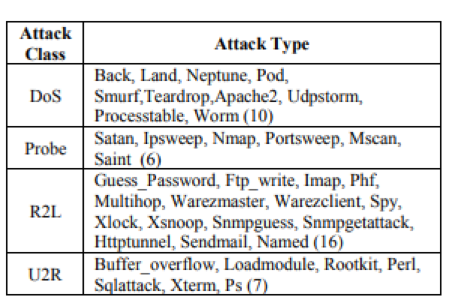

In [22]:
data.head(3)

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,service_freq,flag_freq,src_bytes_log,dst_bytes_log,duration_log,num_compromised_log,num_root_log,hot_log,count_log,srv_count_log
0,0,491,0,0,0,0,0,0,0,0,...,6860,74945,6.198479,0.0,0.0,0.0,0.0,0.0,1.098612,1.098612
1,0,146,0,0,0,0,0,0,0,0,...,4359,74945,4.990433,0.0,0.0,0.0,0.0,0.0,2.639057,0.693147
2,0,0,0,0,0,0,0,0,0,0,...,21853,34851,0.000000,0.0,0.0,0.0,0.0,0.0,4.820282,1.945910


In [23]:
# Атаки по классам

def get_attack_category(attack):
    if attack == 'normal':
        return 'Normal'
    elif attack in ['neptune', 'smurf', 'back', 'pod', 'teardrop', 'land']:
        return 'DOS'
    elif attack in ['satan', 'ipsweep', 'portsweep', 'nmap']:
        return 'Probing'
    elif attack in ['warezclient', 'guess_passwd', 'warezmaster', 'imap', 
                    'ftp_write', 'multihop', 'phf', 'spy']:
        return 'R2L'
    elif attack in ['buffer_overflow', 'rootkit', 'loadmodule', 'perl']:
        return 'U2R'
    else:
        return 'Other'

data['attack_category'] = data['attack'].apply(get_attack_category)

cat_stats = data['attack_category'].value_counts()

print(f"{'Категория':<12} {'Количество':<12} {'Процент':<10}")
for cat, count in cat_stats.items():
    print(f"{cat:<12} {count:<12,} {count/total*100:6.2f}%")

Категория    Количество   Процент   
Normal       67,343        53.46%
DOS          45,927        36.46%
Probing      11,656         9.25%
R2L          995            0.79%
U2R          52             0.04%


КЛАССЫ АТАК:
1.	DOS (отказ в обслуживании) – категория атак, при которых истощаются ресурсы жертвы, что делает её неспособной обрабатывать легитимные запросы (например, SYN-флудинг). Соответствующие признаки: «исходящие байты» и «процент пакетов с ошибками».
2.	Probing (зондирование) – разведывательные и другие зондирующие атаки, цель которых — получить информацию об удалённой жертве (например, сканирование портов). Соответствующие признаки: «длительность соединения» и «исходящие байты».
3.	U2R (несанкционированный доступ к локальному суперпользователю / root) – тип атаки, при котором злоумышленник использует обычную учётную запись для входа в систему-жертву и пытается получить привилегии root/администратора, эксплуатируя некоторые уязвимости жертвы (например, атаки переполнения буфера). Соответствующие признаки: «количество созданий файлов» и «количество вызовов командной оболочки».
4.	R2L (несанкционированный доступ с удалённой машины) – злоумышленник проникает на удалённую машину и получает локальный доступ к системе-жертве (например, подбор пароля). Соответствующие признаки: сетевые характеристики — «длительность соединения» и «запрошенный сервис», а также характеристики на уровне узла — «количество неудачных попыток входа».


In [24]:
data

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_freq,src_bytes_log,dst_bytes_log,duration_log,num_compromised_log,num_root_log,hot_log,count_log,srv_count_log,attack_category
0,0,491,0,0,0,0,0,0,0,0,...,74945,6.198479,0.000000,0.000000,0.0,0.0,0.0,1.098612,1.098612,Normal
1,0,146,0,0,0,0,0,0,0,0,...,74945,4.990433,0.000000,0.000000,0.0,0.0,0.0,2.639057,0.693147,Normal
2,0,0,0,0,0,0,0,0,0,0,...,34851,0.000000,0.000000,0.000000,0.0,0.0,0.0,4.820282,1.945910,DOS
3,0,232,8153,0,0,0,0,0,1,0,...,74945,5.451038,9.006264,0.000000,0.0,0.0,0.0,1.791759,1.791759,Normal
4,0,199,420,0,0,0,0,0,1,0,...,74945,5.298317,6.042633,0.000000,0.0,0.0,0.0,3.433987,3.496508,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,0,0,0,0,0,0,0,0,0,...,34851,0.000000,0.000000,0.000000,0.0,0.0,0.0,5.220356,3.258097,DOS
125969,8,105,145,0,0,0,0,0,0,0,...,74945,4.663439,4.983607,2.197225,0.0,0.0,0.0,1.098612,1.098612,Normal
125970,0,2231,384,0,0,0,0,0,1,0,...,74945,7.710653,5.953243,0.000000,0.0,0.0,0.0,0.693147,0.693147,Normal
125971,0,0,0,0,0,0,0,0,0,0,...,34851,0.000000,0.000000,0.000000,0.0,0.0,0.0,4.976734,2.197225,DOS


In [25]:
data.columns

Index(['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
       'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
       'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
       'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'attack', 'last_flag', 'protocol_type_freq',
       'service_freq', 'flag_freq', 'src_bytes_log', 'dst_bytes_log',
       'duration_log', 'num_compromised_log', 'num_root_log', 'hot_log',
       'count_log', 'srv_count_log',

In [26]:
data_target = data[['attack', 'last_flag']]

In [27]:
# Удаляем столбцы "attack" и "last_flag" из основного датафрейма (не нужны для обучения модели тк attack это целевая метка, а last_flag вспомогательный признак)
data = data.drop(['attack', 'last_flag'], axis=1)

In [28]:
data.shape

(125973, 50)

In [60]:
feature_cols = [
    'duration_log', 'src_bytes_log', 'dst_bytes_log',
    'wrong_fragment', 'hot', 'hot_log',
    'num_compromised_log', 'num_root_log',
    'count', 'srv_count',
    'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
    'protocol_type_freq', 'service_freq', 'flag_freq',
    'logged_in'
]

X = data[feature_cols].copy()

X.shape

(125973, 31)

##  Теоретическое описание метода HBOS

### HBOS (Histogram-Based Outlier Score) — это метод неконтролируемого обнаружения аномалий, основанный на построении гистограмм для выявления выбросов в данных. Он отличается вычислительной эффективностью и простотой реализации.

#### Принцип работы :
#### Построение гистограмм. Для каждого признака (измерения) данных строится одномерная гистограмма. Если признак содержит категориальные данные, выполняется простой подсчёт значений каждой категории и вычисление относительной частоты (высоты гистограммы). Для числовых признаков можно использовать два подхода:
#### 1. Статическая ширина бинов. Гистограмма строится с использованием k бинов равной ширины по диапазону значений.
#### 2. Динамическая ширина бинов. Значения сортируются, а затем фиксированное количество N/k последовательных значений группируется в один бин, где N — общее количество экземпляров, а k — количество бинов.

#### Оценка плотности. Частота выборок в каждом бине используется как оценка плотности. Гистограммы нормализуются так, чтобы максимальная высота равнялась 1,0, что обеспечивает равный вес каждой характеристики при расчёте оценки аномальности. 
#### Расчёт оценки аномалии. Оценка HBOS для каждого экземпляра рассчитывается на основе высоты бинов, в которых он находится

#### Рассмотрим работу HBOS на примере одного числового признака src_bytes_log (количество байт, отправленных от источника к получателю) из нашего датасета сетевого трафика.

In [62]:
feature_data = X['src_bytes_log']

In [63]:
N_BINS = 10  # Количество корзин
ALPHA = 1.0  # Сглаживание (чтобы не было деления на ноль)
N = len(feature_data)  # Общее количество объектов

In [64]:
# Сортируем данные от меньшего к большему
sorted_feature = np.sort(feature_data)

In [65]:
# Вычисляем, сколько объектов должно быть в каждой корзине
base_size = N // N_BINS  # Целая часть от деления
remainder = N % N_BINS   # Остаток от деления

In [66]:
# Создаем границы корзин
bin_edges = [sorted_feature[0]]  # Начинаем с минимального значения
current_idx = 0

In [67]:
for i in range(N_BINS):
    # Определяем размер текущей корзины
    if i < remainder:
        group_size = base_size + 1  # Первые корзины получают на 1 больше
    else:
        group_size = base_size
    
    current_idx += group_size
    
    # Добавляем границу
    if current_idx < N:
        bin_edges.append(sorted_feature[current_idx])
    else:
        # Для последней корзины добавляем максимальное значение
        if len(bin_edges) <= i + 1:
            bin_edges.append(sorted_feature[-1])

In [68]:
bin_edges = np.array(bin_edges)
K = len(bin_edges) - 1  # Количество корзин

print(f"Получилось корзин: {K}")
print(f"Границы корзин:{bin_edges}")
print()

Получилось корзин: 10
Границы корзин:[ 0.          0.          0.          0.          0.69314718  3.80666249
  5.26269019  5.46383181  5.73009978  6.74405919 21.04532317]



In [69]:
# Количество точек в каждой корзине
bin_counts = np.zeros(K)   # Счетчики точек в корзинах
bin_widths = np.zeros(K)   # Ширина каждой корзины

In [70]:
for k in range(K):
    left = bin_edges[k]      # Левая граница корзины
    right = bin_edges[k+1]   # Правая граница корзины
    
    # Считаем, сколько точек попало в эту корзину
    if k == 0:
        # Первая корзина: включаем левую границу
        count = np.sum((feature_data >= left) & (feature_data <= right))
    else:
        # Остальные корзины: левая граница не включается
        count = np.sum((feature_data > left) & (feature_data <= right))
    
    bin_counts[k] = count
    bin_widths[k] = max(right - left, 1e-10)  # Ширина корзины

In [71]:
#Плотность для каждой корзины: (количество точек + ALPHA) / ((N + ALPHA*K) * ширина) чем больше точек в корзине, тем выше плотность
denominator = (N + ALPHA * K) * bin_widths
f_jk = (bin_counts + ALPHA) / denominator
log_f_jk = -np.log(np.maximum(f_jk, 1e-10))  # Логарифм обратной плотности

In [72]:
# Вычисляем HBOS скор для каждого объекта
# Для каждого объекта определяем, в какую корзину он попал, и берем соответствующий HBOS вклад из этой корзины
# Определяем номер корзины для каждого значения
hbos_scores = np.zeros(N)
for i, val in enumerate(feature_data):
    # Ищем корзину, куда попадает val
    k = 0
    for j in range(K):
        if j == 0:
            if val <= bin_edges[j+1]:
                k = j
                break
        else:
            if bin_edges[j] < val <= bin_edges[j+1]:
                k = j
                break
    hbos_scores[i] = log_f_jk[k]
print(f"Минимальный скор: {hbos_scores.min():.4f}")
print(f"Максимальный скор: {hbos_scores.max():.4f}")
print(f"Средний скор: {hbos_scores.mean():.4f}")
print()

Минимальный скор: -22.0895
Максимальный скор: 4.9638
Средний скор: -7.1058



In [73]:
#Определяем аномалии (объекты с наибольшими скорами)
threshold = np.percentile(hbos_scores, 95) 
anomaly_indices = np.where(hbos_scores >= threshold)[0]
print(f"Порог аномалии (95-й перцентиль): {threshold:.4f}")
print(f"Количество аномалий: {len(anomaly_indices)} из {N} ({len(anomaly_indices)/N*100:.1f}%)")
print()

Порог аномалии (95-й перцентиль): 4.9638
Количество аномалий: 12586 из 125973 (10.0%)



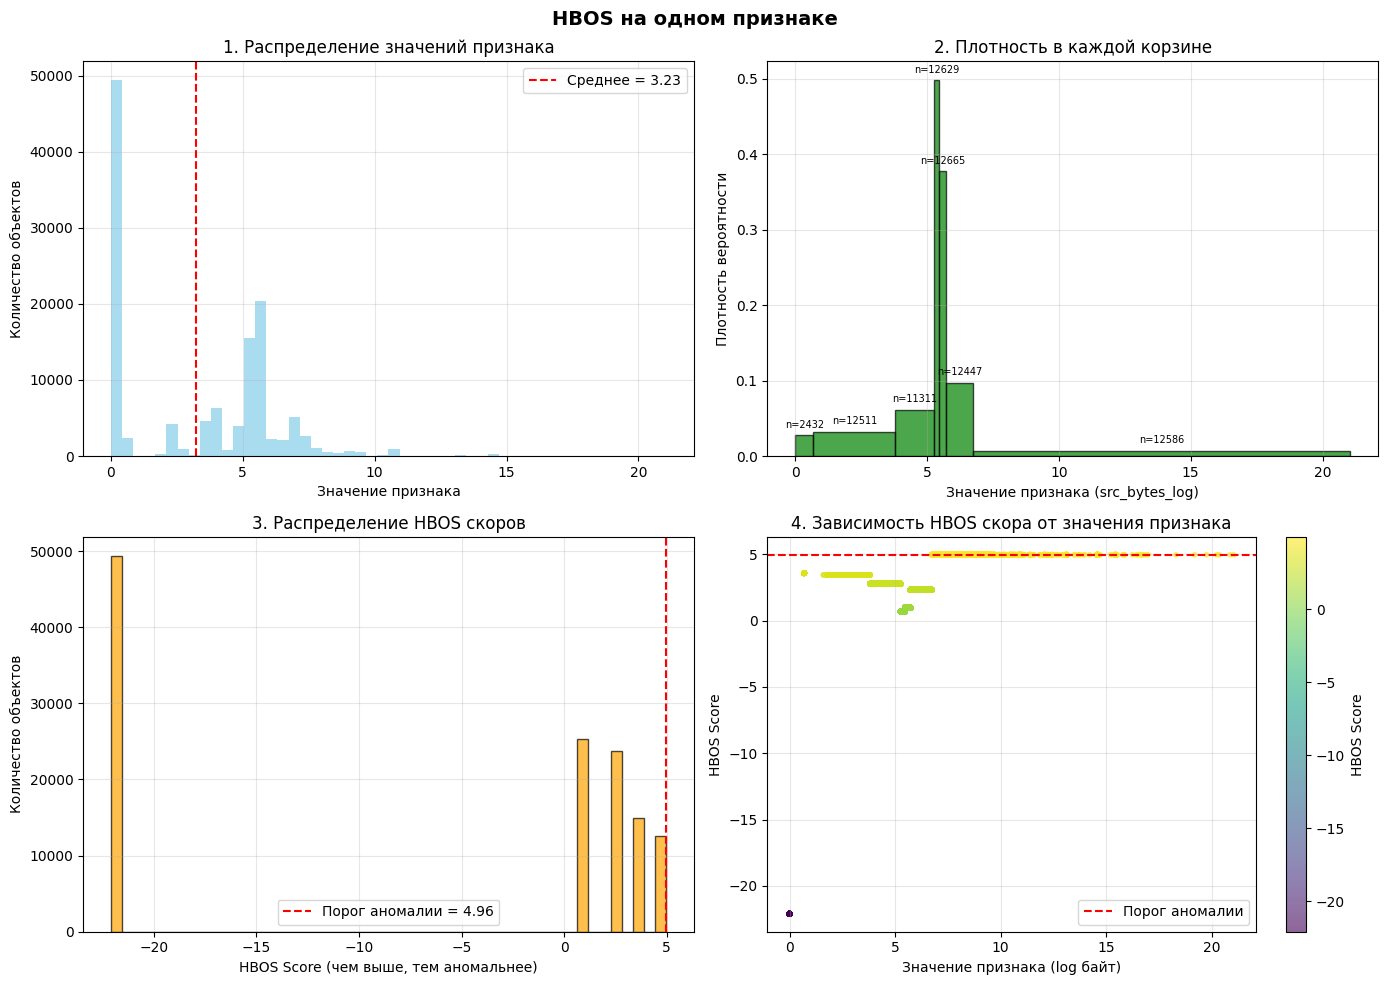

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Гистограмма распределения признака
axes[0, 0].hist(feature_data, bins=50, color='skyblue', alpha=0.7)
axes[0, 0].axvline(feature_data.mean(), color='red', linestyle='--', 
                   label=f'Среднее = {feature_data.mean():.2f}')
axes[0, 0].set_title('1. Распределение значений признака')
axes[0, 0].set_xlabel('Значение признака')
axes[0, 0].set_ylabel('Количество объектов')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# График 2: Корзины и их плотность
for k in range(K):
    if bin_widths[k] > 1e-6:  # Показываем только реальные корзины
        x_center = (bin_edges[k] + bin_edges[k+1]) / 2
        axes[0, 1].bar(x_center, f_jk[k], width=bin_widths[k], 
                       color='green', edgecolor='black', alpha=0.7)
        axes[0, 1].text(x_center, f_jk[k] + 0.01, f'n={int(bin_counts[k])}', 
                        ha='center', fontsize=7)

axes[0, 1].set_title(f'2. Плотность в каждой корзине (K={K}, показаны корзины с шириной > 0)')
axes[0, 1].set_xlabel('Значение признака')
axes[0, 1].set_ylabel('Плотность вероятности')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 1].set_title('2. Плотность в каждой корзине')
axes[0, 1].set_xlabel('Значение признака (src_bytes_log)')
axes[0, 1].set_ylabel('Плотность вероятности')
axes[0, 1].grid(True, alpha=0.3)

# График 3: Распределение HBOS скоров
axes[1, 0].hist(hbos_scores, bins=50, color='orange', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(threshold, color='red', linestyle='--', 
                   label=f'Порог аномалии = {threshold:.2f}')
axes[1, 0].set_title('3. Распределение HBOS скоров')
axes[1, 0].set_xlabel('HBOS Score (чем выше, тем аномальнее)')
axes[1, 0].set_ylabel('Количество объектов')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# График 4: Связь между значением признака и HBOS скором
scatter = axes[1, 1].scatter(feature_data, hbos_scores, c=hbos_scores, 
                               s=10, alpha=0.6)
axes[1, 1].axhline(threshold, color='red', linestyle='--', label='Порог аномалии')
axes[1, 1].set_title('4. Зависимость HBOS скора от значения признака')
axes[1, 1].set_xlabel('Значение признака (log байт)')
axes[1, 1].set_ylabel('HBOS Score')
axes[1, 1].legend()
plt.colorbar(scatter, ax=axes[1, 1], label='HBOS Score')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('HBOS на одном признаке', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### HBOS успешно выделил аномалии в сетевом трафике:

#### 10% объектов (12,586 из 125,973) признаны аномальными

#### Норма — соединения с нулевой или типичной передачей данных (скоры от -22 до 4.96)

#### Метод корректно работает: адаптивные корзины подстроились под распределение, порог срабатывания = 4.96

### HBOS позволяет быстро выявлять подозрительные сетевые соединения (например, потенциальные DoS-атаки или утечки данных) без использования размеченных данных.



### Преимущества метода HBOS

Тестирование на разных размерах данных:
Размер данных        Время (сек)     Скорость (строк/сек)
    10,000 строк           0.310 сек            32,286
    50,000 строк           1.512 сек            33,074
   100,000 строк           3.907 сек            25,595
   125,973 строк           4.814 сек            26,167


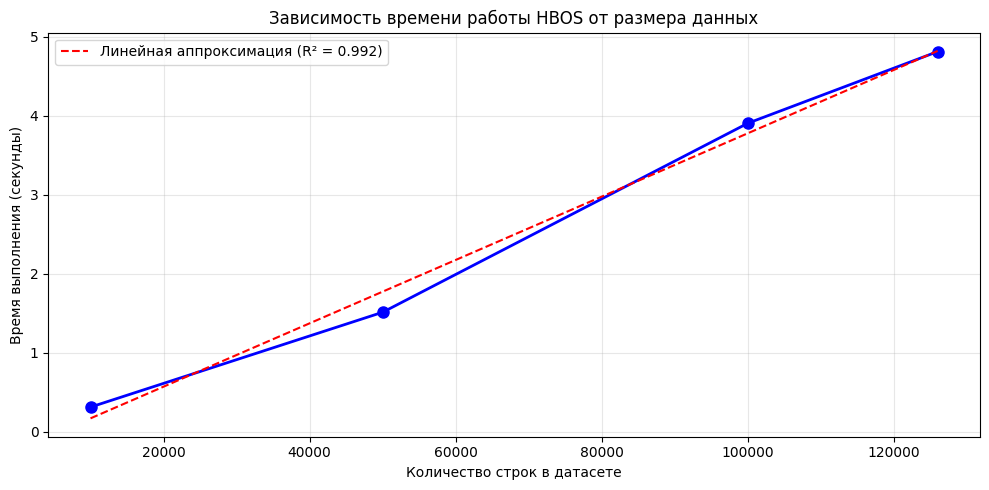


 HBOS демонстрирует линейную зависимость времени от объема данных


In [81]:
# Измерение времени метода HBOS 
def benchmark_hbos(data, n_bins=20):
    start = time.time()
    N, D = data.shape
    scores = np.zeros(N)
    for j in range(D):
        feature = data[:, j]
        sorted_feature = np.sort(feature)
        
        # Адаптивные корзины
        base_size = N // n_bins
        remainder = N % n_bins
        
        bin_edges = [sorted_feature[0]]
        current = 0
        
        for i in range(n_bins):
            if i < remainder:
                current += base_size + 1
            else:
                current += base_size
            if current < N:
                bin_edges.append(sorted_feature[current])
            elif len(bin_edges) <= i + 1:
                bin_edges.append(sorted_feature[-1])
        
        bin_edges = np.array(bin_edges)
        K = len(bin_edges) - 1
        
        # Подсчет точек в корзинах
        counts = np.zeros(K)
        widths = np.zeros(K)
        
        for k in range(K):
            left, right = bin_edges[k], bin_edges[k+1]
            if k == 0:
                counts[k] = np.sum((feature >= left) & (feature <= right))
            else:
                counts[k] = np.sum((feature > left) & (feature <= right))
            widths[k] = max(right - left, 1e-10)
        # Плотность и HBOS вклад
        alpha = 1.0
        denom = (N + alpha * K) * widths
        density = (counts + alpha) / denom
        hbos_contrib = -np.log(density + 1e-10)
        
        # Расчет скоров
        for i, val in enumerate(feature):
            k = 0
            for idx in range(K):
                if idx == 0:
                    if val <= bin_edges[idx+1]:
                        k = idx
                        break
                else:
                    if bin_edges[idx] < val <= bin_edges[idx+1]:
                        k = idx
                        break
            scores[i] += hbos_contrib[k]
    
    elapsed = time.time() - start
    return elapsed

# Тестируем на данных разного размера
print("Тестирование на разных размерах данных:")
print(f"{'Размер данных':<20} {'Время (сек)':<15} {'Скорость (строк/сек)':<20}")
sizes = [10000, 50000, 100000, len(X)]
times = []
for size in sizes:
    if size <= len(X):
        data_sample = X.values[:size]
        elapsed = benchmark_hbos(data_sample, n_bins=20)
        times.append(elapsed)
        speed = size / elapsed
        print(f"{size:>10,} строк        {elapsed:>8.3f} сек      {speed:>12,.0f}")

# Визуализация зависимости времени от размера
plt.figure(figsize=(10, 5))
plt.plot(sizes[:len(times)], times, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Количество строк в датасете')
plt.ylabel('Время выполнения (секунды)')
plt.title('Зависимость времени работы HBOS от размера данных')
plt.grid(True, alpha=0.3)

# Добавляем линию тренда
if len(times) > 1:
    z = np.polyfit(sizes[:len(times)], times, 1)
    p = np.poly1d(z)
    plt.plot(sizes[:len(times)], p(sizes[:len(times)]), "r--", 
             label=f'Линейная аппроксимация (R² = {np.corrcoef(sizes[:len(times)], times)[0,1]**2:.3f})')
    plt.legend()

plt.tight_layout()
plt.show()

print("\n HBOS демонстрирует линейную зависимость времени от объема данных")

##### HBOS обрабатывает 125 тысяч записей за 4.8 секунды со скоростью 26,000 строк/сек, демонстрируя линейную зависимость времени от объема данных (R²=0.992), что подтверждает его высокую эффективность для задач обнаружения аномалий в реальном времени.

## Реализация HBOS для корзин с фиксированной шириной

Так как условием реализции HBOS служит предпосылка о независимости признаков, применим РСА для данных 

In [30]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
from factor_analyzer.factor_analyzer import calculate_kmo
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [31]:
# Тест сферичности Барлетта на применение РСА
chi_square_value,p_value=calculate_bartlett_sphericity(X)
chi_square_value, round(p_value, 5)

(np.float64(5620866.982651772), np.float64(0.0))

В тесте Бартлетта p-значение равно близким к 0. Тест был статистически значимым, что указывало на то, что наблюдаемая корреляционная матрица не является единичной матрицей

In [32]:
# Тест Кайзера-Мейера-Олкина (КМО)
kmo_all,kmo_model=calculate_kmo(X)
kmo_model

np.float64(0.8346092842307297)

Общий КМО больше 0.6, значит можно использовать РСА

**Стандартизация**

HBOS чувствителен к масштабу признака: чем больше дисперсия признака, тем больше ширина корзин, что приводит к более грубой оценке плотности. В итоге HBOS будет детектировать аномалии только в признаках с малым дисперсией. Также это необходимо и для применения РСА

In [33]:
sc=StandardScaler()
X_sc = sc.fit_transform(X)

**РСА**

In [34]:
df1 = pd.DataFrame(X_sc)              # ndarray в DataFrame, исходные данные стандартизированы
df1.columns = df1.columns+1
df1.index = df1.index + 1

In [35]:
dcorr=df1.corr()   #  применяется к DataFrame

In [36]:
eigenvalues, eigenvectors = np.linalg.eig(dcorr)

In [37]:
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:,idx]

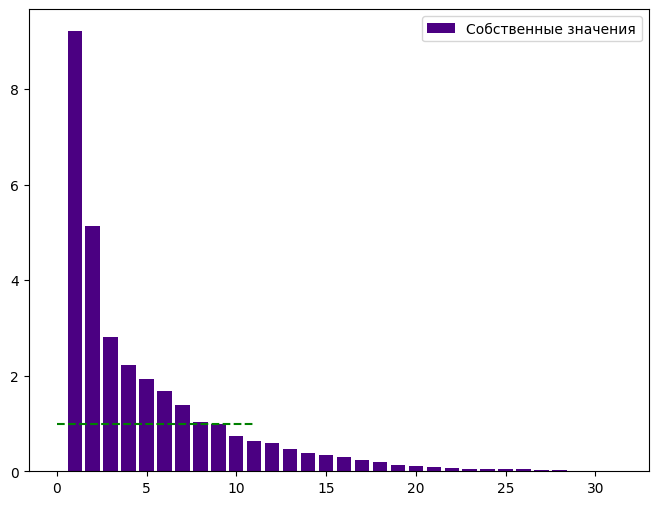

In [38]:
# Критерий Кайзера (графически)

fig, ax = plt.subplots(1,1, figsize = (8,6))
ax.bar(range(1, len(eigenvalues)+1), eigenvalues, label = 'Собственные значения', color = 'indigo')
ax.plot(np.full(12, 1), '--',color='green')
ax.legend()
plt.show()

In [39]:
# Объясненная сумма дисперсии
eigenvalues / np.sum(eigenvalues)*100
np.cumsum(eigenvalues)/ np.sum(eigenvalues)*100

array([ 29.72105616,  46.28125795,  55.38078717,  62.54988083,
        68.8040716 ,  74.24773015,  78.74757025,  82.10054817,
        85.26285317,  87.65925653,  89.68233265,  91.57955535,
        93.1164425 ,  94.37527156,  95.44541628,  96.41452938,
        97.19818877,  97.85698804,  98.27405147,  98.59849317,
        98.91415516,  99.12735067,  99.30939697,  99.46946769,
        99.61851452,  99.74888815,  99.86278554,  99.91856325,
        99.95771943,  99.98684092, 100.        ])

In [40]:
pca = PCA(n_components=9)  # 9 компонент объясняют 85% дисперсии
score_new = pca.fit_transform(X_sc)

**Алгоритм HBOS**
- вычисление диапазона aj, bj для каждого признака
- задание фиксированной ширины hj
- построение гистограммы, подсчет nj,k для k = 1,.., Kj (сколько точек попало в корзину)
- оценка плотности
- преобразование в логарифм

In [41]:
BIN_WIDTH = 0.5  # Фиксированная ширина корзины (бин) для всех признаков
ALPHA = 1.0 # Параметр сглаживания альфа для избежания нулевых вероятностей, если в корзину не попадает ни одно из значений

N = score_new.shape[0]  # Количество строк
D = score_new.shape[1]  # Количество признаков

# ШАГ 1: ВЫЧИСЛЕНИЕ ДИАПАЗОНА [a_j, b_j] ДЛЯ КАЖДОГО ПРИЗНАКА

a_list = []  
b_list = []  

for j in range(D):

    feature_j = score_new[:, j]
    a_j = np.min(feature_j)
    b_j = np.max(feature_j)
    
    a_list.append(a_j)
    b_list.append(b_j)

a_array = np.array(a_list)
b_array = np.array(b_list)

# ШАГ 2 ВЫЧИСЛЕНИЕ ЧИСЛА КОРЗИН K_j И ШИРИНЫ h_j

K_list = [] # список для хранения числа корзин для каждого признака

for j in range(D):
    
    range_j = b_array[j] - a_array[j]
    K_j = max(1, int(np.ceil(range_j / BIN_WIDTH))) # Вычисляем число корзин по формуле: K_j = (b_j - a_j) / h_j, округляем до целого числа и убеждаемся, что минимум 1 корзина
    
    K_list.append(K_j)

K_array = np.array(K_list)

h_list = []
for j in range(D):
    range_j = b_array[j] - a_array[j] # Теперь вычисляем фактическую ширину корзин для каждого признака h_j = (b_j - a_j) / K_j
    h_j = range_j / K_array[j]
    h_list.append(h_j)

h_array = np.array(h_list)

# ШАГ 3: ПОСТРОЕНИЕ ГИСТОГРАММЫ - ПОДСЧЁТ n_{j,k}

histograms = {} # Ключ: номер признака j, Значение: массив счётчиков n_{j,k}

for j in range(D):
    
    feature_j = score_new[:, j]
    K_j = K_array[j]
    a_j = a_array[j]
    b_j = b_array[j]
    
    n_jk = np.zeros(K_j) # Создаём массив для подсчёта попаданий в корзины, инициализируем нулями (длина K_j)

    for i in range(N):
        
        x_ij = feature_j[i]
        k = int((x_ij - a_j) / h_array[j]) # Определяем, в какую корзину попадает это значение k = floor((x - a_j) / h_j)
        
        k = min(k, K_j - 1) # индекс корзины должен находиться в допустимых пределах (последнее значение может попасть за границу)
        k = max(k, 0)
        
        n_jk[k] += 1
    
    histograms[j] = n_jk
    
# ШАГ 4: ОЦЕНКА ПЛОТНОСТИ f_{j,k} = (n_{j,k} + α) / ((N + α*K_j) * h_j)

density_estimates = {}

for j in range(D):

    n_jk = histograms[j]
    K_j = K_array[j]
    h_j = h_array[j]
    
    
    denominator = (N + ALPHA * K_j) * h_j # знаменатель формулы: (N + α*K_j) * h_j
    numerator = n_jk + ALPHA # Вычисляем оценку плотности для каждой корзины, числитель: n_{j,k} + α
    f_jk = numerator / denominator # Оценка плотности: f_{j,k} = numerator / denominator

    density_estimates[j] = f_jk
    
# ШАГ 5: ПРЕОБРАЗОВАНИЕ В ЛОГАРИФМ L_{j,k} = -log(f_{j,k})

log_tables = {}

for j in range(D):
    f_jk = density_estimates[j]

    L_jk = -np.log(f_jk + 1e-10) # Используем натуральный логарифм (np.log), добавляем маленькое число (1e-10), чтобы избежать log(0) - эпсилон

    log_tables[j] = L_jk
    
# ШАГ 6: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ {a_j, h_j, L_{j,k}}

hbos_model = {}

for j in range(D):
    hbos_model[j] = {
        'a_j': a_array[j],           # Левая граница диапазона
        'h_j': h_array[j],           # Ширина корзины
        'K_j': K_array[j],           # Число корзин
        'L_jk': log_tables[j]        # Логарифмическая таблица
    }

print("Сохранённые параметры для каждого признака:")

for j in range(D):
    print(f"\nПризнак {j+1}:")
    print(f"  a_{j} = {hbos_model[j]['a_j']:.4f}")
    print(f"  h_{j} = {hbos_model[j]['h_j']:.4f}")
    print(f"  K_{j} = {hbos_model[j]['K_j']}")

# ШАГ 7: ВЫЧИСЛЕНИЕ HBOS-СКОРА ДЛЯ ОБЪЕКТОВ HBOS(x_i) = Σ L_{j,k} для всех признаков j

hbos_scores = np.zeros(N)

for i in range(N):
    total_score = 0
    
    for j in range(D):
        x_ij = score_new[i, j]
        a_j = hbos_model[j]['a_j']
        h_j = hbos_model[j]['h_j']
        K_j = hbos_model[j]['K_j']
        L_jk = hbos_model[j]['L_jk']
 
        k = int((x_ij - a_j) / h_j) # Определяем номер корзины
        k = min(k, K_j - 1)
        k = max(k, 0)
        
        total_score += L_jk[k]

    hbos_scores[i] = total_score

print(f"Средний HBOS-скор: {np.mean(hbos_scores):.3f}")
print(f"Стандартное отклонение: {np.std(hbos_scores):.3f}")

# Находим наиболее аномальные объекты (с наибольшими HBOS-скорами)
top_anomalies = np.argsort(hbos_scores)[::-1][:10]
print(f"\nТоп-10 наиболее аномальных объектов (индексы): {top_anomalies}")
print(f"Их HBOS: {hbos_scores[top_anomalies]}")

Сохранённые параметры для каждого признака:

Признак 1:
  a_0 = -5.5410
  h_0 = 0.4983
  K_0 = 21

Признак 2:
  a_1 = -2.1564
  h_1 = 0.4802
  K_1 = 20

Признак 3:
  a_2 = -6.0416
  h_2 = 0.4897
  K_2 = 23

Признак 4:
  a_3 = -2.1076
  h_3 = 0.4975
  K_3 = 72

Признак 5:
  a_4 = -11.3032
  h_4 = 0.4907
  K_4 = 34

Признак 6:
  a_5 = -10.6134
  h_5 = 0.4994
  K_5 = 146

Признак 7:
  a_6 = -24.6591
  h_6 = 0.4951
  K_6 = 63

Признак 8:
  a_7 = -2.4868
  h_7 = 0.4864
  K_7 = 29

Признак 9:
  a_8 = -5.6467
  h_8 = 0.4888
  K_8 = 30
Средний HBOS-скор: 9.654
Стандартное отклонение: 7.282

Топ-10 наиболее аномальных объектов (индексы): [ 59734  80343 111610  74650  87054 106279  22990  47227  23954  65558]
Их HBOS: [83.75200913 70.65481951 70.44803124 70.39302009 69.6352696  69.43470454
 68.68103365 67.27324684 66.06472892 63.92688894]


In [42]:
X_pca_df = pd.DataFrame(score_new, columns=[f'PC{i+1}' for i in range(score_new.shape[1])])
X_pca_df['hbos_scores_myself'] = hbos_scores

In [43]:
X_pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,hbos_scores_myself
0,0.688141,-0.040897,-0.654663,0.440501,-0.167428,-0.014799,0.517225,0.289013,-0.174548,8.769617
1,-0.540832,0.812078,-3.055177,1.240914,0.106448,0.248122,2.471777,-0.209163,0.635854,18.907873
2,-3.680710,-2.106002,0.611452,-0.208981,-0.413370,-0.050222,-0.052378,0.144776,-0.149175,3.276606
3,3.229380,-0.666099,1.562069,-0.616580,-0.362436,-0.000866,0.109335,-0.057172,-0.020329,3.910936
4,2.823792,-0.545784,1.261890,-0.635324,0.857064,0.173298,0.205257,0.002931,-0.072751,5.103539


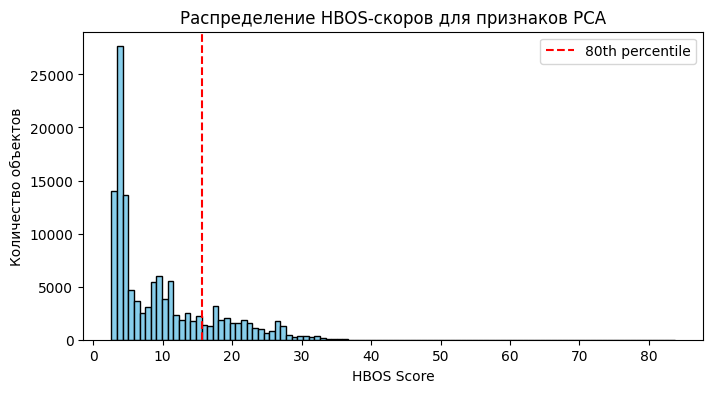

In [44]:
plt.figure(figsize=(8, 4))
plt.hist(hbos_scores, bins=100, color='skyblue', edgecolor='black')
plt.axvline(np.percentile(hbos_scores, 80), color='red', linestyle='--', label='80th percentile')
plt.xlabel('HBOS Score')
plt.ylabel('Количество объектов')
plt.title('Распределение HBOS-скоров для признаков РСА')
plt.legend()
plt.show()

In [45]:
# поставим границу для аномалий в 0.8 
contamination = 0.2
threshold = np.percentile(hbos_scores, 100 * (1 - contamination))
hbos_labels = (hbos_scores > threshold).astype(int)
X_pca_df['hbos_scores_labels_myself'] = hbos_labels
X_pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,hbos_scores_myself,hbos_scores_labels_myself
0,0.688141,-0.040897,-0.654663,0.440501,-0.167428,-0.014799,0.517225,0.289013,-0.174548,8.769617,0
1,-0.540832,0.812078,-3.055177,1.240914,0.106448,0.248122,2.471777,-0.209163,0.635854,18.907873,1
2,-3.680710,-2.106002,0.611452,-0.208981,-0.413370,-0.050222,-0.052378,0.144776,-0.149175,3.276606,0
3,3.229380,-0.666099,1.562069,-0.616580,-0.362436,-0.000866,0.109335,-0.057172,-0.020329,3.910936,0
4,2.823792,-0.545784,1.261890,-0.635324,0.857064,0.173298,0.205257,0.002931,-0.072751,5.103539,0


In [46]:
X_pca_df['hbos_scores_labels_myself'].value_counts()

hbos_scores_labels_myself
0    100829
1     25144
Name: count, dtype: int64

In [47]:
from pyod.models.hbos import HBOS

In [48]:
# Встроенный метод 
hbos = HBOS(n_bins=10,      # количество бинов для гистограмм
            alpha=0.1,      # вес для ортогональности (0-1)
            tol=0.5)        # порог для выбросов

hbos.fit(score_new)

scores = hbos.decision_function(score_new)  
labels = hbos.labels_  # 1 - аномалия, 0 - норма

**HBOS для стандартизованных данных без применения РСА**

In [49]:
BIN_WIDTH = 0.5  # Фиксированная ширина корзины (бин) для всех признаков
ALPHA = 1.0 # Параметр сглаживания альфа для избежания нулевых вероятностей, если в корзину не попадает ни одно из значений

N = X_sc.shape[0]  # Количество строк
D = X_sc.shape[1]  # Количество признаков

# ШАГ 1: ВЫЧИСЛЕНИЕ ДИАПАЗОНА [a_j, b_j] ДЛЯ КАЖДОГО ПРИЗНАКА

a_list = []  
b_list = []  

for j in range(D):

    feature_j = X_sc[:, j]
    a_j = np.min(feature_j)
    b_j = np.max(feature_j)
    
    a_list.append(a_j)
    b_list.append(b_j)

a_array = np.array(a_list)
b_array = np.array(b_list)

# ШАГ 2 ВЫЧИСЛЕНИЕ ЧИСЛА КОРЗИН K_j И ШИРИНЫ h_j

K_list = [] # список для хранения числа корзин для каждого признака

for j in range(D):
    
    range_j = b_array[j] - a_array[j]
    K_j = max(1, int(np.ceil(range_j / BIN_WIDTH))) # Вычисляем число корзин по формуле: K_j = (b_j - a_j) / h_j, округляем до целого числа и убеждаемся, что минимум 1 корзина
    
    K_list.append(K_j)

K_array = np.array(K_list)

h_list = []
for j in range(D):
    range_j = b_array[j] - a_array[j] # Теперь вычисляем фактическую ширину корзин для каждого признака h_j = (b_j - a_j) / K_j
    h_j = range_j / K_array[j]
    h_list.append(h_j)

h_array = np.array(h_list)

# ШАГ 3: ПОСТРОЕНИЕ ГИСТОГРАММЫ - ПОДСЧЁТ n_{j,k}

histograms = {} # Ключ: номер признака j, Значение: массив счётчиков n_{j,k}

for j in range(D):
    
    feature_j = X_sc[:, j]
    K_j = K_array[j]
    a_j = a_array[j]
    b_j = b_array[j]
    
    n_jk = np.zeros(K_j) # Создаём массив для подсчёта попаданий в корзины, инициализируем нулями (длина K_j)

    for i in range(N):
        
        x_ij = feature_j[i]
        k = int((x_ij - a_j) / h_array[j]) # Определяем, в какую корзину попадает это значение k = floor((x - a_j) / h_j)
        
        k = min(k, K_j - 1) # индекс корзины должен находиться в допустимых пределах (последнее значение может попасть за границу)
        k = max(k, 0)
        
        n_jk[k] += 1
    
    histograms[j] = n_jk
    
# ШАГ 4: ОЦЕНКА ПЛОТНОСТИ f_{j,k} = (n_{j,k} + α) / ((N + α*K_j) * h_j)

density_estimates = {}

for j in range(D):

    n_jk = histograms[j]
    K_j = K_array[j]
    h_j = h_array[j]
    
    
    denominator = (N + ALPHA * K_j) * h_j # знаменатель формулы: (N + α*K_j) * h_j
    numerator = n_jk + ALPHA # Вычисляем оценку плотности для каждой корзины, числитель: n_{j,k} + α
    f_jk = numerator / denominator # Оценка плотности: f_{j,k} = numerator / denominator

    density_estimates[j] = f_jk
    
# ШАГ 5: ПРЕОБРАЗОВАНИЕ В ЛОГАРИФМ L_{j,k} = -log(f_{j,k})

log_tables = {}

for j in range(D):
    f_jk = density_estimates[j]

    L_jk = -np.log(f_jk + 1e-10) # Используем натуральный логарифм (np.log), добавляем маленькое число (1e-10), чтобы избежать log(0) - эпсилон

    log_tables[j] = L_jk
    
# ШАГ 6: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ {a_j, h_j, L_{j,k}}

hbos_model = {}

for j in range(D):
    hbos_model[j] = {
        'a_j': a_array[j],           # Левая граница диапазона
        'h_j': h_array[j],           # Ширина корзины
        'K_j': K_array[j],           # Число корзин
        'L_jk': log_tables[j]        # Логарифмическая таблица
    }

print("Сохранённые параметры для каждого признака:")

for j in range(D):
    print(f"\nПризнак {j+1}:")
    print(f"  a_{j} = {hbos_model[j]['a_j']:.4f}")
    print(f"  h_{j} = {hbos_model[j]['h_j']:.4f}")
    print(f"  K_{j} = {hbos_model[j]['K_j']}")

# ШАГ 7: ВЫЧИСЛЕНИЕ HBOS-СКОРА ДЛЯ ОБЪЕКТОВ HBOS(x_i) = Σ L_{j,k} для всех признаков j

hbos_scores = np.zeros(N)

for i in range(N):
    total_score = 0
    
    for j in range(D):
        x_ij = X_sc[i, j]
        a_j = hbos_model[j]['a_j']
        h_j = hbos_model[j]['h_j']
        K_j = hbos_model[j]['K_j']
        L_jk = hbos_model[j]['L_jk']
 
        k = int((x_ij - a_j) / h_j) # Определяем номер корзины
        k = min(k, K_j - 1)
        k = max(k, 0)
        
        total_score += L_jk[k]

    hbos_scores[i] = total_score

print(f"Средний HBOS-скор: {np.mean(hbos_scores):.3f}")
print(f"Стандартное отклонение: {np.std(hbos_scores):.3f}")

# Находим наиболее аномальные объекты (с наибольшими HBOS-скорами)
top_anomalies = np.argsort(hbos_scores)[::-1][:10]
print(f"\nТоп-10 наиболее аномальных объектов (индексы): {top_anomalies}")
print(f"Их HBOS: {hbos_scores[top_anomalies]}")

Сохранённые параметры для каждого признака:

Признак 1:
  a_0 = -0.2216
  h_0 = 0.4900
  K_0 = 15

Признак 2:
  a_1 = -1.0830
  h_1 = 0.4705
  K_1 = 15

Признак 3:
  a_2 = -0.8691
  h_2 = 0.4930
  K_2 = 12

Признак 4:
  a_3 = -0.0895
  h_3 = 0.4930
  K_3 = 24

Признак 5:
  a_4 = -0.0951
  h_4 = 0.4974
  K_4 = 72

Признак 6:
  a_5 = -0.1279
  h_5 = 0.4999
  K_5 = 29

Признак 7:
  a_6 = -0.0701
  h_6 = 0.4964
  K_6 = 111

Признак 8:
  a_7 = -0.0553
  h_7 = 0.4971
  K_7 = 105

Признак 9:
  a_8 = -0.7345
  h_8 = 0.4958
  K_8 = 9

Признак 10:
  a_9 = -0.3819
  h_9 = 0.4690
  K_9 = 15

Признак 11:
  a_10 = -0.6372
  h_10 = 0.4480
  K_10 = 5

Признак 12:
  a_11 = -0.6319
  h_11 = 0.4474
  K_11 = 5

Признак 13:
  a_12 = -0.3744
  h_12 = 0.4458
  K_12 = 7

Признак 14:
  a_13 = -0.3744
  h_13 = 0.4414
  K_13 = 7

Признак 15:
  a_14 = -1.5034
  h_14 = 0.4549
  K_14 = 5

Признак 16:
  a_15 = -0.3497
  h_15 = 0.4622
  K_15 = 12

Признак 17:
  a_16 = -0.3746
  h_16 = 0.4811
  K_16 = 8

Признак 18:
 

In [50]:
X_sc_df = pd.DataFrame(X_sc, columns=feature_cols)
X_sc_df['hbos_scores_myself'] = hbos_scores

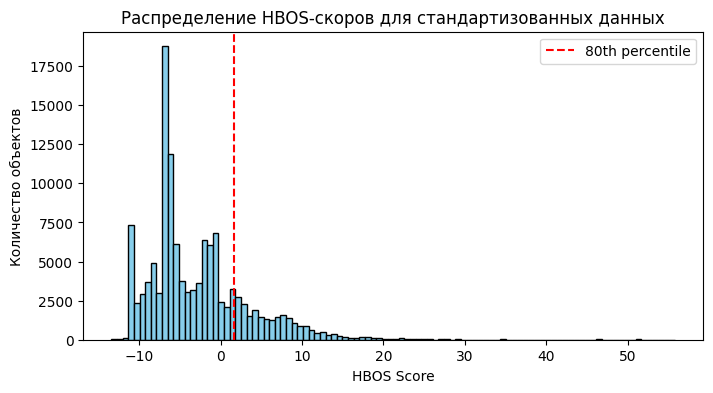

In [51]:
plt.figure(figsize=(8, 4))
plt.hist(hbos_scores, bins=100, color='skyblue', edgecolor='black')
plt.axvline(np.percentile(hbos_scores, 80), color='red', linestyle='--', label='80th percentile')
plt.xlabel('HBOS Score')
plt.ylabel('Количество объектов')
plt.title('Распределение HBOS-скоров для стандартизованных данных')
plt.legend()
plt.show()

In [52]:
# поставим границу для аномалий в 0.8 
contamination = 0.2
threshold = np.percentile(hbos_scores, 100 * (1 - contamination))
hbos_labels = (hbos_scores > threshold).astype(int)
X_sc_df['hbos_scores_labels_myself'] = hbos_labels
X_sc_df.head()

,duration_log,src_bytes_log,dst_bytes_log,wrong_fragment,hot,hot_log,num_compromised_log,num_root_log,count,srv_count,...,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type_freq,service_freq,flag_freq,logged_in,hbos_scores_myself,hbos_scores_labels_myself
0,-0.221617,0.995517,-0.869111,-0.089486,-0.095076,-0.127866,-0.070058,-0.055255,-0.717045,-0.354343,...,-0.639532,-0.624871,-0.224532,-0.376387,0.475805,-0.728254,0.782064,-0.809262,-7.464399,0
1,-0.221617,0.590429,-0.869111,-0.089486,-0.095076,-0.127866,-0.070058,-0.055255,-0.620982,-0.368110,...,-0.639532,-0.624871,-0.387635,-0.376387,-2.030238,-0.881565,0.782064,-0.809262,-0.631576,0
2,-0.221617,-1.082990,-0.869111,-0.089486,-0.095076,-0.127866,-0.070058,-0.055255,0.339648,-0.299273,...,1.608759,1.618955,-0.387635,-0.376387,0.475805,0.190812,-0.813914,-0.809262,-6.198954,0
3,-0.221617,0.744881,1.668642,-0.089486,-0.095076,-0.127866,-0.070058,-0.055255,-0.690846,-0.313041,...,-0.572083,-0.602433,-0.387635,-0.345084,0.475805,1.323938,0.782064,1.235694,0.416455,0
4,-0.221617,0.693670,0.833560,-0.089486,-0.095076,-0.127866,-0.070058,-0.055255,-0.472521,0.058678,...,-0.639532,-0.624871,-0.387635,-0.376387,0.475805,1.323938,0.782064,1.235694,-11.252073,0


In [53]:
X_sc_df['hbos_scores_labels_myself'].value_counts()

hbos_scores_labels_myself
0    100793
1     25180
Name: count, dtype: int64

**Для стандартизованных данных применим метод HBOS для гиперпараметров, которые были подобраны вручную и приближают нас к изначальным меткам**

In [54]:
NUM_BINS = 8  # Фиксированное количество корзин для всех признаков (можно менять)
ALPHA = 1.0    # Параметр сглаживания для избежания нулевых вероятностей

N = X_sc.shape[0]  # Количество строк
D = X_sc.shape[1]  # Количество признаков

# ШАГ 1: ВЫЧИСЛЕНИЕ ДИАПАЗОНА [a_j, b_j] ДЛЯ КАЖДОГО ПРИЗНАКА
a_list = []  
b_list = []  

for j in range(D):
    feature_j = X_sc[:, j]
    a_j = np.min(feature_j)
    b_j = np.max(feature_j)
    
    a_list.append(a_j)
    b_list.append(b_j)

a_array = np.array(a_list)
b_array = np.array(b_list)

# ШАГ 2: ВЫЧИСЛЕНИЕ ШИРИНЫ КОРЗИН h_j 

K_array = np.full(D, NUM_BINS)  # Теперь число корзин одинаково для всех признаков

h_list = []
for j in range(D):
    range_j = b_array[j] - a_array[j]
    # Если размах = 0 (все значения одинаковы), ставим минимальную ширину, чтобы не делить на 0
    h_j = range_j / NUM_BINS if range_j > 0 else 1e-5
    h_list.append(h_j)

h_array = np.array(h_list)

print(f"Фиксированное число корзин: {NUM_BINS}")
print("Фактические ширины корзин:")
for j in range(D):
    print(f"  Признак {j+1}: h_{j} = {h_array[j]:.4f} (диапазон: {b_array[j]-a_array[j]:.3f})")
print("-" * 50)

# ШАГ 3: ПОСТРОЕНИЕ ГИСТОГРАММЫ - ПОДСЧЁТ n_{j,k}
histograms = {}

for j in range(D):
    feature_j = X_sc[:, j]
    K_j = K_array[j]  # Теперь это константа NUM_BINS
    a_j = a_array[j]
    b_j = b_array[j]
    
    n_jk = np.zeros(K_j)

    for i in range(N):
        x_ij = feature_j[i]
        k = int((x_ij - a_j) / h_array[j])
        
        k = min(k, K_j - 1)
        k = max(k, 0)
        
        n_jk[k] += 1
    
    histograms[j] = n_jk
    
# ШАГ 4: ОЦЕНКА ПЛОТНОСТИ f_{j,k}
density_estimates = {}

for j in range(D):
    n_jk = histograms[j]
    K_j = K_array[j]
    h_j = h_array[j]
    
    denominator = (N + ALPHA * K_j) * h_j
    numerator = n_jk + ALPHA
    f_jk = numerator / denominator

    density_estimates[j] = f_jk
    
# ШАГ 5: ПРЕОБРАЗОВАНИЕ В ЛОГАРИФМ L_{j,k} = -log(f_{j,k})
log_tables = {}

for j in range(D):
    f_jk = density_estimates[j]
    L_jk = -np.log(f_jk + 1e-10)
    log_tables[j] = L_jk
    
# ШАГ 6: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ {a_j, h_j, L_{j,k}}
hbos_model = {}

for j in range(D):
    hbos_model[j] = {
        'a_j': a_array[j],
        'h_j': h_array[j],
        'K_j': K_array[j],
        'L_jk': log_tables[j]
    }

print("Сохранённые параметры для каждого признака:")
for j in range(D):
    print(f"\nПризнак {j+1}:")
    print(f"  a_{j} = {hbos_model[j]['a_j']:.4f}")
    print(f"  h_{j} = {hbos_model[j]['h_j']:.4f}")
    print(f"  K_{j} = {hbos_model[j]['K_j']}")

# ШАГ 7: ВЫЧИСЛЕНИЕ HBOS-СКОРА ДЛЯ ОБЪЕКТОВ
hbos_scores = np.zeros(N)

for i in range(N):
    total_score = 0
    
    for j in range(D):
        x_ij = X_sc[i, j]
        a_j = hbos_model[j]['a_j']
        h_j = hbos_model[j]['h_j']
        K_j = hbos_model[j]['K_j']
        L_jk = hbos_model[j]['L_jk']
 
        k = int((x_ij - a_j) / h_j)
        k = min(k, K_j - 1)
        k = max(k, 0)
        
        total_score += L_jk[k]

    hbos_scores[i] = total_score

print(f"\nСредний HBOS-скор: {np.mean(hbos_scores):.3f}")
print(f"Стандартное отклонение: {np.std(hbos_scores):.3f}")

top_anomalies = np.argsort(hbos_scores)[::-1][:10]
print(f"\nТоп-10 наиболее аномальных объектов (индексы): {top_anomalies}")
print(f"Их HBOS: {hbos_scores[top_anomalies]}")

Фиксированное число корзин: 8
Фактические ширины корзин:
  Признак 1: h_0 = 0.9187 (диапазон: 7.349)
  Признак 2: h_1 = 0.8821 (диапазон: 7.057)
  Признак 3: h_2 = 0.7394 (диапазон: 5.915)
  Признак 4: h_3 = 1.4791 (диапазон: 11.833)
  Признак 5: h_4 = 4.4768 (диапазон: 35.815)
  Признак 6: h_5 = 1.8121 (диапазон: 14.497)
  Признак 7: h_6 = 6.8875 (диапазон: 55.100)
  Признак 8: h_7 = 6.5241 (диапазон: 52.193)
  Признак 9: h_8 = 0.5578 (диапазон: 4.463)
  Признак 10: h_9 = 0.8794 (диапазон: 7.035)
  Признак 11: h_10 = 0.2800 (диапазон: 2.240)
  Признак 12: h_11 = 0.2796 (диапазон: 2.237)
  Признак 13: h_12 = 0.3901 (диапазон: 3.121)
  Признак 14: h_13 = 0.3862 (диапазон: 3.090)
  Признак 15: h_14 = 0.2843 (диапазон: 2.275)
  Признак 16: h_15 = 0.6932 (диапазон: 5.546)
  Признак 17: h_16 = 0.4811 (диапазон: 3.849)
  Признак 18: h_17 = 0.3213 (диапазон: 2.570)
  Признак 19: h_18 = 0.2879 (диапазон: 2.303)
  Признак 20: h_19 = 0.2784 (диапазон: 2.227)
  Признак 21: h_20 = 0.6617 (диапазон

In [55]:
X_sc_special_df = pd.DataFrame(X_sc, columns=feature_cols)
X_sc_special_df['hbos_scores_myself'] = hbos_scores

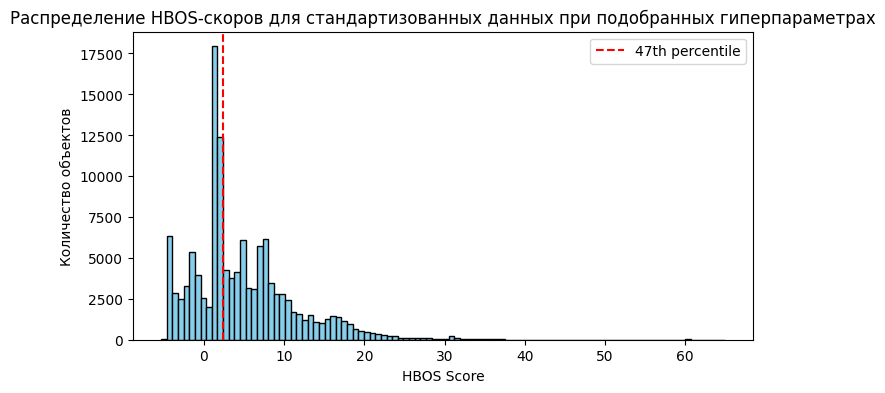

In [56]:
plt.figure(figsize=(8, 4))
plt.hist(hbos_scores, bins=100, color='skyblue', edgecolor='black')
plt.axvline(np.percentile(hbos_scores, 47), color='red', linestyle='--', label='47th percentile')
plt.xlabel('HBOS Score')
plt.ylabel('Количество объектов')
plt.title('Распределение HBOS-скоров для стандартизованных данных при подобранных гиперпараметрах')
plt.legend()
plt.show()

In [57]:
# поставим границу для аномалий в 0.8 
contamination = 0.53
threshold = np.percentile(hbos_scores, 100 * (1 - contamination))
hbos_labels = (hbos_scores > threshold).astype(int)
X_sc_special_df['hbos_scores_labels_myself'] = hbos_labels
X_sc_special_df.head()

,duration_log,src_bytes_log,dst_bytes_log,wrong_fragment,hot,hot_log,num_compromised_log,num_root_log,count,srv_count,...,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type_freq,service_freq,flag_freq,logged_in,hbos_scores_myself,hbos_scores_labels_myself
0,-0.221617,0.995517,-0.869111,-0.089486,-0.095076,-0.127866,-0.070058,-0.055255,-0.717045,-0.354343,...,-0.639532,-0.624871,-0.224532,-0.376387,0.475805,-0.728254,0.782064,-0.809262,3.368763,1
1,-0.221617,0.590429,-0.869111,-0.089486,-0.095076,-0.127866,-0.070058,-0.055255,-0.620982,-0.368110,...,-0.639532,-0.624871,-0.387635,-0.376387,-2.030238,-0.881565,0.782064,-0.809262,8.040237,1
2,-0.221617,-1.082990,-0.869111,-0.089486,-0.095076,-0.127866,-0.070058,-0.055255,0.339648,-0.299273,...,1.608759,1.618955,-0.387635,-0.376387,0.475805,0.190812,-0.813914,-0.809262,1.857691,0
3,-0.221617,0.744881,1.668642,-0.089486,-0.095076,-0.127866,-0.070058,-0.055255,-0.690846,-0.313041,...,-0.572083,-0.602433,-0.387635,-0.345084,0.475805,1.323938,0.782064,1.235694,8.200816,1
4,-0.221617,0.693670,0.833560,-0.089486,-0.095076,-0.127866,-0.070058,-0.055255,-0.472521,0.058678,...,-0.639532,-0.624871,-0.387635,-0.376387,0.475805,1.323938,0.782064,1.235694,-4.296254,0


In [58]:
X_sc_special_df['hbos_scores_labels_myself'].value_counts()

hbos_scores_labels_myself
1    66762
0    59211
Name: count, dtype: int64

**Матрица ошибок** и сравнение количества корзин РСА

In [59]:
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, precision_score, recall_score

y_true = (data_target['attack'] != 'normal').astype(int)

def run_hbos_scores(X_sc, n_bins, alpha=1.0):
    N, D = X_sc.shape
    
    # Шаг 1: Диапазоны
    a_arr = np.min(X_sc, axis=0)
    b_arr = np.max(X_sc, axis=0)
    
    # Шаг 2: Ширины корзин
    h_arr = np.array([(b_arr[j] - a_arr[j]) / n_bins if (b_arr[j] - a_arr[j]) > 0 else 1e-5 
                      for j in range(D)]) 
    
    # Шаг 3: Гистограммы 
    histograms = {}
    for j in range(D):
        # Определяем индекс корзины для всех объектов сразу
        k_idx = np.floor((X_sc[:, j] - a_arr[j]) / h_arr[j]).astype(int)
        k_idx = np.clip(k_idx, 0, n_bins - 1)  # Обрезка границ
        histograms[j] = np.bincount(k_idx, minlength=n_bins)  # Подсчёт попаданий
        
    # Шаг 4-5: Плотность и логарифмические таблицы
    log_tables = {}
    for j in range(D):
        n_jk = histograms[j]
        denom = (N + alpha * n_bins) * h_arr[j]
        f_jk = (n_jk + alpha) / denom
        log_tables[j] = -np.log(f_jk + 1e-10)  # L_{j,k}
        
    # Шаг 6: Вычисление скоров
    scores = np.zeros(N)
    for i in range(N):
        s = 0.0
        for j in range(D):
            k = int((X_sc[i, j] - a_arr[j]) / h_arr[j])
            k = max(0, min(k, n_bins - 1))
            s += log_tables[j][k]
        scores[i] = s
    return scores

# ПОДБОР NUM_BINS ЧЕРЕЗ СРАВНЕНИЕ МАТРИЦ ОШИБОК

bins_candidates = [5, 10, 15, 20, 25, 30]  
results = []

for nb in bins_candidates:

    scores = run_hbos_scores(X_sc, n_bins=nb)
    
    # Порог: верхние 20% считаем аномалиями 
    threshold = np.percentile(scores, 80)
    y_pred = (scores > threshold).astype(int)
    
    cm = confusion_matrix(y_true, y_pred) # матрица ошибок и метрики
    tn, fp, fn, tp = cm.ravel()
    
    metrics = {
        'NUM_BINS': nb,
        'Confusion_Matrix': cm,
        'F1_Score': f1_score(y_true, y_pred),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
    }
    results.append(metrics)
    print(f"  NUM_BINS={nb:2d} | F1={metrics['F1_Score']:.3f} | Acc={metrics['Accuracy']:.3f} | TP={tp:5d}, FP={fp:4d}, FN={fn:4d}, TN={tn:5d}")


# ВЫБОР ЛУЧШЕГО ПАРАМЕТРА
results_df = pd.DataFrame(results)

# Выбираем строку с максимальным F1-score
best = results_df.loc[results_df['F1_Score'].idxmax()]

print(f"ЛУЧШИЙ ПАРАМЕТР: NUM_BINS = {int(best['NUM_BINS'])}")
print(f"Итоговые метрики: F1={best['F1_Score']:.3f}, Accuracy={best['Accuracy']:.3f}")
print(f"Precision={best['Precision']:.3f}, Recall={best['Recall']:.3f}")
print("Лучшая матрица ошибок:")
print(best['Confusion_Matrix'])

final_scores = run_hbos_scores(X_sc, n_bins=int(best['NUM_BINS']))
final_threshold = np.percentile(final_scores, 80)
final_labels = (final_scores > final_threshold).astype(int)

KeyboardInterrupt: 

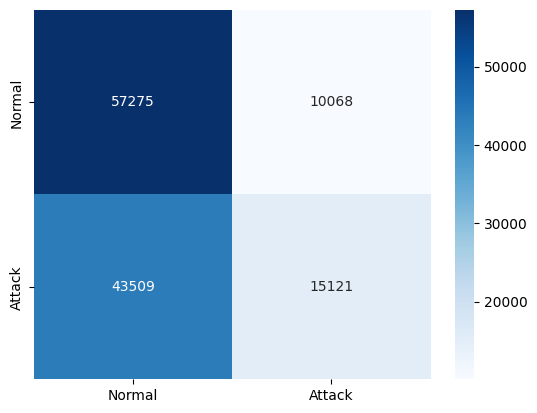

In [ ]:
sns.heatmap(best['Confusion_Matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.show()

## ЕСЛИ ПОДСТАВЛЯЮ ДРУГИЕ КОРЗИНЫ ТО ВЫГИРЫВАЕТ ОПЯТЬ НАИМЕНЬШАЯ ЭТО СТРАННО 

In [ ]:
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, precision_score, recall_score

y_true = (data_target['attack'] != 'normal').astype(int)

def run_hbos_scores(X_sc, n_bins, alpha=1.0):
    N, D = X_sc.shape
    
    # Шаг 1: Диапазоны
    a_arr = np.min(X_sc, axis=0)
    b_arr = np.max(X_sc, axis=0)
    
    # Шаг 2: Ширины корзин
    h_arr = np.array([(b_arr[j] - a_arr[j]) / n_bins if (b_arr[j] - a_arr[j]) > 0 else 1e-5 
                      for j in range(D)]) 
    
    # Шаг 3: Гистограммы 
    histograms = {}
    for j in range(D):
        # Определяем индекс корзины для всех объектов сразу
        k_idx = np.floor((X_sc[:, j] - a_arr[j]) / h_arr[j]).astype(int)
        k_idx = np.clip(k_idx, 0, n_bins - 1)  # Обрезка границ
        histograms[j] = np.bincount(k_idx, minlength=n_bins)  # Подсчёт попаданий
        
    # Шаг 4-5: Плотность и логарифмические таблицы
    log_tables = {}
    for j in range(D):
        n_jk = histograms[j]
        denom = (N + alpha * n_bins) * h_arr[j]
        f_jk = (n_jk + alpha) / denom
        log_tables[j] = -np.log(f_jk + 1e-10)  # L_{j,k}
        
    # Шаг 6: Вычисление скоров
    scores = np.zeros(N)
    for i in range(N):
        s = 0.0
        for j in range(D):
            k = int((X_sc[i, j] - a_arr[j]) / h_arr[j])
            k = max(0, min(k, n_bins - 1))
            s += log_tables[j][k]
        scores[i] = s
    return scores

# ПОДБОР NUM_BINS ЧЕРЕЗ СРАВНЕНИЕ МАТРИЦ ОШИБОК

bins_candidates = [3, 5, 6, 7, 8, 20, 30, 50, 75, 100] 
results = []

for nb in bins_candidates:

    scores = run_hbos_scores(X_sc, n_bins=nb)
    
    # Порог: верхние 20% считаем аномалиями 
    threshold = np.percentile(scores, 80)
    y_pred = (scores > threshold).astype(int)
    
    cm = confusion_matrix(y_true, y_pred) # матрица ошибок и метрики
    tn, fp, fn, tp = cm.ravel()
    
    metrics = {
        'NUM_BINS': nb,
        'Confusion_Matrix': cm,
        'F1_Score': f1_score(y_true, y_pred),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
    }
    results.append(metrics)
    print(f"  NUM_BINS={nb:2d} | F1={metrics['F1_Score']:.3f} | Acc={metrics['Accuracy']:.3f} | TP={tp:5d}, FP={fp:4d}, FN={fn:4d}, TN={tn:5d}")


# ВЫБОР ЛУЧШЕГО ПАРАМЕТРА
results_df = pd.DataFrame(results)

# Выбираем строку с максимальным F1-score
best = results_df.loc[results_df['F1_Score'].idxmax()]

print(f"ЛУЧШИЙ ПАРАМЕТР: NUM_BINS = {int(best['NUM_BINS'])}")
print(f"Итоговые метрики: F1={best['F1_Score']:.3f}, Accuracy={best['Accuracy']:.3f}")
print(f"Precision={best['Precision']:.3f}, Recall={best['Recall']:.3f}")
print("Лучшая матрица ошибок:")
print(best['Confusion_Matrix'])

final_scores = run_hbos_scores(X_sc, n_bins=int(best['NUM_BINS']))
final_threshold = np.percentile(final_scores, 80)
final_labels = (final_scores > final_threshold).astype(int)

  NUM_BINS= 3 | F1=0.405 | Acc=0.605 | TP=16900, FP=7967, FN=41730, TN=59376
  NUM_BINS= 5 | F1=0.361 | Acc=0.575 | TP=15121, FP=10068, FN=43509, TN=57275
  NUM_BINS= 6 | F1=0.329 | Acc=0.553 | TP=13768, FP=11425, FN=44862, TN=55918
  NUM_BINS= 7 | F1=0.301 | Acc=0.535 | TP=12613, FP=12571, FN=46017, TN=54772
  NUM_BINS= 8 | F1=0.296 | Acc=0.532 | TP=12423, FP=12768, FN=46207, TN=54575
  NUM_BINS=20 | F1=0.305 | Acc=0.537 | TP=12776, FP=12416, FN=45854, TN=54927
  NUM_BINS=30 | F1=0.300 | Acc=0.534 | TP=12564, FP=12629, FN=46066, TN=54714
  NUM_BINS=50 | F1=0.286 | Acc=0.525 | TP=11983, FP=13210, FN=46647, TN=54133
  NUM_BINS=75 | F1=0.288 | Acc=0.526 | TP=12058, FP=13137, FN=46572, TN=54206
  NUM_BINS=100 | F1=0.267 | Acc=0.512 | TP=11200, FP=13995, FN=47430, TN=53348
ЛУЧШИЙ ПАРАМЕТР: NUM_BINS = 3
Итоговые метрики: F1=0.405, Accuracy=0.605
Precision=0.680, Recall=0.288
Лучшая матрица ошибок:
[[59376  7967]
 [41730 16900]]


# Учитывая, что известен процент атак встроенный метод (Диана)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
# Используем для оценки качества (в саму модель не подаём!)
true_labels = (data['attack_category'] != 'Normal').astype(int)
contamination = true_labels.mean()  # доля аномалий в данных

In [ ]:
# Без РСА но стандартизованные (X_sc)
bins_list = [3, 5, 6, 7, 8, 9, 10, 20, 30, 50, 75, 100]
results_static = []
for n_bins in bins_list:
    model = HBOS(n_bins=n_bins, alpha=0.1, tol=0.5, contamination=0.4654)
    model.fit(X_sc)

    preds  = model.labels_
    scores = model.decision_scores_

 # Считаем метрики
    prec = precision_score(true_labels, preds)
    rec  = recall_score(true_labels, preds)
    f1   = f1_score(true_labels, preds)
    auc  = roc_auc_score(true_labels, scores)

    results_static.append({
        'n_bins': n_bins,
        'Precision': round(prec, 3),
        'Recall':    round(rec, 3),
        'F1':        round(f1, 3),
        'ROC-AUC':   round(auc, 3),
        'Аномалий':  int(preds.sum())
    })
    print(f"n_bins={n_bins:>3}: Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}  AUC={auc:.3f}  аномалий={int(preds.sum()):,}")


n_bins=  3: Precision=0.789  Recall=0.789  F1=0.789  AUC=0.860  аномалий=58,624
n_bins=  5: Precision=0.642  Recall=0.633  F1=0.637  AUC=0.774  аномалий=57,738
n_bins=  6: Precision=0.612  Recall=0.584  F1=0.598  AUC=0.760  аномалий=55,980
n_bins=  7: Precision=0.584  Recall=0.582  F1=0.583  AUC=0.725  аномалий=58,461
n_bins=  8: Precision=0.537  Recall=0.528  F1=0.533  AUC=0.693  аномалий=57,644
n_bins=  9: Precision=0.510  Recall=0.510  F1=0.510  AUC=0.674  аномалий=58,623
n_bins= 10: Precision=0.505  Recall=0.505  F1=0.505  AUC=0.669  аномалий=58,573
n_bins= 20: Precision=0.528  Recall=0.528  F1=0.528  AUC=0.660  аномалий=58,624
n_bins= 30: Precision=0.565  Recall=0.565  F1=0.565  AUC=0.681  аномалий=58,628
n_bins= 50: Precision=0.519  Recall=0.519  F1=0.519  AUC=0.638  аномалий=58,628
n_bins= 75: Precision=0.511  Recall=0.511  F1=0.511  AUC=0.635  аномалий=58,628
n_bins=100: Precision=0.507  Recall=0.507  F1=0.507  AUC=0.613  аномалий=58,628


наилучшая при 3 корзинах

In [ ]:
# Для РСА (score_new)
bins_list = [3, 5, 6, 7, 8, 9, 10, 20, 30, 50, 75, 100]
results_static = []
for n_bins in bins_list:
    model = HBOS(n_bins=n_bins, alpha=0.1, tol=0.5, contamination=0.4654)
    model.fit(score_new)

    preds  = model.labels_
    scores = model.decision_scores_

 # Считаем метрики
    prec = precision_score(true_labels, preds)
    rec  = recall_score(true_labels, preds)
    f1   = f1_score(true_labels, preds)
    auc  = roc_auc_score(true_labels, scores)

    results_static.append({
        'n_bins': n_bins,
        'Precision': round(prec, 3),
        'Recall':    round(rec, 3),
        'F1':        round(f1, 3),
        'ROC-AUC':   round(auc, 3),
        'Аномалий':  int(preds.sum())
    })
    print(f"n_bins={n_bins:>3}: Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}  AUC={auc:.3f}  аномалий={int(preds.sum()):,}")


n_bins=  3: Precision=0.472  Recall=0.412  F1=0.440  AUC=0.714  аномалий=51,178
n_bins=  5: Precision=0.446  Recall=0.444  F1=0.445  AUC=0.395  аномалий=58,461
n_bins=  6: Precision=0.449  Recall=0.427  F1=0.438  AUC=0.594  аномалий=55,767
n_bins=  7: Precision=0.611  Recall=0.599  F1=0.605  AUC=0.696  аномалий=57,568
n_bins=  8: Precision=0.522  Recall=0.519  F1=0.520  AUC=0.668  аномалий=58,285
n_bins=  9: Precision=0.488  Recall=0.456  F1=0.472  AUC=0.633  аномалий=54,718
n_bins= 10: Precision=0.447  Recall=0.446  F1=0.447  AUC=0.508  аномалий=58,503
n_bins= 20: Precision=0.449  Recall=0.449  F1=0.449  AUC=0.498  аномалий=58,621
n_bins= 30: Precision=0.446  Recall=0.445  F1=0.445  AUC=0.492  аномалий=58,502
n_bins= 50: Precision=0.446  Recall=0.445  F1=0.445  AUC=0.464  аномалий=58,628
n_bins= 75: Precision=0.454  Recall=0.454  F1=0.454  AUC=0.443  аномалий=58,628
n_bins=100: Precision=0.446  Recall=0.446  F1=0.446  AUC=0.444  аномалий=58,617


Наилучшая при 7 корзинах

In [ ]:
columns = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
"wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
"root_shell","su_attempted","num_root","num_file_creations","num_shells",
"num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
"srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
"same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
"dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
"dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
"dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
"attack","last_flag"]
data = pd.read_csv('Network_anomaly_data.txt', header=None, names=columns)
data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,last_flag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
# Атаки по классам

def get_attack_category(attack):
    if attack == 'normal':
        return 'Normal'
    elif attack in ['neptune', 'smurf', 'back', 'pod', 'teardrop', 'land']:
        return 'DOS'
    elif attack in ['satan', 'ipsweep', 'portsweep', 'nmap']:
        return 'Probing'
    elif attack in ['warezclient', 'guess_passwd', 'warezmaster', 'imap', 
                    'ftp_write', 'multihop', 'phf', 'spy']:
        return 'R2L'
    elif attack in ['buffer_overflow', 'rootkit', 'loadmodule', 'perl']:
        return 'U2R'
    else:
        return 'Other'

data['attack_category'] = data['attack'].apply(get_attack_category)

cat_stats = data['attack_category'].value_counts()

print(f"{'Категория':<12} {'Количество':<12} {'Процент':<10}")
for cat, count in cat_stats.items():
    print(f"{cat:<12} {count:<12,} {count/total*100:6.2f}%")

Категория    Количество   Процент   
Normal       67,343        53.46%
DOS          45,927        36.46%
Probing      11,656         9.25%
R2L          995            0.79%
U2R          52             0.04%


In [ ]:
# Для РСА
bins_list = [7]
for n_bins in bins_list:
    model = HBOS(n_bins=n_bins, alpha=0.1, tol=0.5, contamination=0.4654)
    model.fit(score_new)

    preds_1  = model.labels_
    scores = model.decision_scores_

    print(f"n_bins={n_bins:>3}: аномалий={preds_1.sum():,}  норма={(preds_1==0).sum():,}")

n_bins=  7: аномалий=57,568  норма=68,405


In [ ]:
# Попробую ответить на вопрос: Проанализируйте полученные результаты. 
# Относятся ли выявленные аномалии трафика к каким-либо типам атак? 
# Добавляем результат HBOS в dataframe
data['hbos_label_1'] = preds_1

In [ ]:
data[data['hbos_label_1'] == 1]['attack'].value_counts()

attack
normal             22420
neptune            18194
ipsweep             3599
satan               3544
portsweep           2916
smurf               2614
nmap                1260
back                 956
teardrop             892
warezclient          822
pod                  201
guess_passwd          53
land                  18
warezmaster           17
buffer_overflow       14
imap                  10
rootkit                9
loadmodule             9
ftp_write              7
multihop               6
perl                   3
phf                    2
spy                    2
Name: count, dtype: int64

Анализ результатов применения метода HBOS показал, что среди выявленных аномалий присутствуют как реальные сетевые атаки (например, neptune, satan, ipsweep), так и значительное количество нормального трафика. Это объясняется тем, что алгоритм HBOS не использует метки классов при обучении и определяет аномалии исключительно на основе статистической редкости наблюдений. 

##### Аналогично для стандартизованных данных без РСА 

In [ ]:
bins_list = [3]
for n_bins in bins_list:
    model = HBOS(n_bins=n_bins, alpha=0.1, tol=0.5, contamination=0.4654)
    model.fit(X_sc)

    preds_2  = model.labels_
    scores = model.decision_scores_

    print(f"n_bins={n_bins:>3}: аномалий={preds_2.sum():,}  норма={(preds_2==0).sum():,}")

n_bins=  3: аномалий=58,624  норма=67,349


In [ ]:
data['hbos_label_2'] = preds_2

In [ ]:
data[data['hbos_label_2'] == 1]['attack'].value_counts()

attack
neptune            32572
normal             12350
ipsweep             3182
satan               2986
portsweep           2920
smurf               1943
nmap                1295
teardrop             467
back                 427
warezclient          213
pod                  159
guess_passwd          52
buffer_overflow       19
land                  18
imap                  10
loadmodule             6
multihop               2
ftp_write              2
phf                    1
Name: count, dtype: int64

Но все равно много нормального трафика

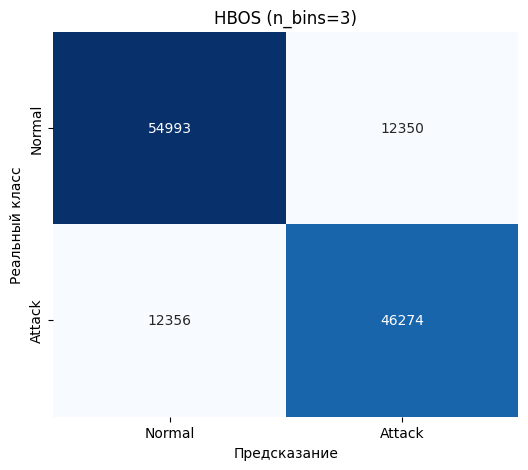

In [ ]:
# Для стандартизованных матрица ошибок
cm = confusion_matrix(
    (data['attack_category'] != 'Normal').astype(int),
    data['hbos_label_2']
)

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack'],
    cbar=False
)

ax.set_title('HBOS (n_bins=3)')
ax.set_xlabel('Предсказание')
ax.set_ylabel('Реальный класс')

plt.show()

Таким образом: <br>
реально Normal и модель сказала Normal: 54993 <br>
реально Normal но модель сказала Attack: 12350 <br>
реально Attack но модель сказала Normal: 12356 <br>
реально Attack и модель сказала Attack: 46274

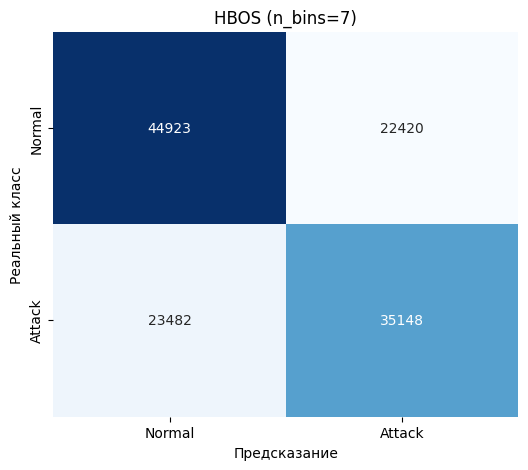

In [ ]:
# Для РСА матрица ошибок
cm = confusion_matrix(
    (data['attack_category'] != 'Normal').astype(int),
    data['hbos_label_1']
)

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack'],
    cbar=False
)

ax.set_title('HBOS (n_bins=7)')
ax.set_xlabel('Предсказание')
ax.set_ylabel('Реальный класс')

plt.show()

Таким образом: <br>
реально Normal и модель сказала Normal: 34834 <br>
реально Normal но модель сказала Attack: 32509 <br>
реально Attack но модель сказала Normal: 32511 <br>
реально Attack и модель сказала Attack: 26119

## Реализация HBOS для корзин с адаптивной шириной (Ангелина)

#### Для РСА

In [ ]:
N_BINS = 20           # Количество корзин (каждая содержит примерно N/N_BINS точек)
ALPHA = 1.0           # Параметр сглаживания для избежания нулевых вероятностей

N = score_new.shape[0]  # Количество строк (объектов)
D = score_new.shape[1]  # Количество столбцов (признаков)

all_bin_edges = []      # границы корзин для каждого признака
all_bin_widths = []     # ширина каждой корзины (разная!)
all_bin_counts = []     # количество точек в каждой корзине
all_log_tables = []     # логарифмическая таблица L_{j,k}

# ШАГ 1: ДЛЯ КАЖДОГО ПРИЗНАКА СТРОИМ АДАПТИВНЫЕ КОРЗИНЫ

for j in range(D):
    
    feature_j = score_new[:, j]
    sorted_feature = np.sort(feature_j)
    
    base_size = N // N_BINS        # базовый размер группы
    remainder = N % N_BINS         # остаток (первые remainder групп будут на 1 больше)

    # границы корзин
    bin_edges = [sorted_feature[0]]   # начинаем с минимального значения
    current_idx = 0
    
    for i in range(N_BINS):
        # определяем размер текущей группы
        if i < remainder:
            group_size = base_size + 1
        else:
            group_size = base_size
        
        # перемещаем индекс на размер группы
        current_idx += group_size
        
        # добавляем границу
        if current_idx < N:
            bin_edges.append(sorted_feature[current_idx])
        else:
            # если это последняя группа, добавляем максимальное значение
            if len(bin_edges) <= i + 1:
                bin_edges.append(sorted_feature[-1])


# ШАГ 2 ВЫЧИСЛЯЕМ ЧИСЛА КОРЗИН K_j И ШИРИНЫ 
    
    K_j = len(bin_edges) - 1          # количество корзин для этого признака
    bin_widths = np.zeros(K_j)        # ширина каждой корзины
    bin_counts = np.zeros(K_j)        # количество точек в каждой корзине
    
    # Подсчитываем точки в каждой корзине
    for k in range(K_j):
        left = bin_edges[k]
        right = bin_edges[k + 1]
        
        # Для первой корзины включаем левую границу
        if k == 0:
            count = np.sum((feature_j >= left) & (feature_j <= right))
        else:
            count = np.sum((feature_j > left) & (feature_j <= right))
        
        bin_counts[k] = count
        bin_widths[k] = right - left
        
        # Защита от нулевой ширины
        if bin_widths[k] <= 0:
            bin_widths[k] = 1e-10
    
   
# ШАГ 3: ОЦЕНКА ПЛОТНОСТИ f_{j,k} = (n_{j,k} + α) / ((N + α*K_j) * h_{j,k})
   
    denominator = (N + ALPHA * K_j) * bin_widths
    numerator = bin_counts + ALPHA
    densities = numerator / denominator

    log_table = -np.log(np.maximum(densities, 1e-10))
    
    all_bin_edges.append(bin_edges)
    all_bin_widths.append(bin_widths)
    all_bin_counts.append(bin_counts)
    all_log_tables.append(log_table)
    

# ШАГ 3: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ {h_j, L_{j,k}} ДЛЯ КАЖДОГО ПРИЗНАКА

hbos_model = {}

for j in range(D):
    hbos_model[j] = {
        'bin_edges': all_bin_edges[j],        # Все границы корзин
        'bin_widths': all_bin_widths[j],      # Ширина каждой корзины (массив, разная!)
        'K_j': len(all_bin_edges[j]) - 1,     # Число корзин
        'L_jk': all_log_tables[j]             # Логарифмическая таблица
    }

print("Сохранённые параметры для каждого признака:")

for j in range(D):  # Показываем первые 5 признаков
    print(f"\nПризнак {j+1}:")
    print(f"  K_{j} = {hbos_model[j]['K_j']}")
    print(f"  Ширина корзин (h_{j}): мин={hbos_model[j]['bin_widths'].min():.4f}, макс={hbos_model[j]['bin_widths'].max():.4f}")


# ШАГ 4: ВЫЧИСЛЕНИЕ HBOS-СКОРА ДЛЯ ОБЪЕКТОВ HBOS(x_i) = Σ L_{j,k} для всех признаков j

hbos_scores = np.zeros(N)

for i in range(N):
    total_score = 0
    
    for j in range(D):
        x_ij = score_new[i, j]
        
        # Получаем параметры для признака j
        bin_edges = hbos_model[j]['bin_edges']
        K_j = hbos_model[j]['K_j']
        L_jk = hbos_model[j]['L_jk']
        
        # Определяем номер корзины
        k = np.digitize(x_ij, bin_edges) - 1
        k = min(k, K_j - 1)
        k = max(k, 0)
        
        total_score += L_jk[k]

    hbos_scores[i] = total_score

print(f"\nСтатистика HBOS-скоров:")
print(f"  Минимум: {hbos_scores.min():.3f}")
print(f"  Максимум: {hbos_scores.max():.3f}")
print(f"  Средний: {np.mean(hbos_scores):.3f}")
print(f"  Стандартное отклонение: {np.std(hbos_scores):.3f}")


# Находим наиболее аномальные объекты (с наибольшими HBOS-скорами)

print(f"\nТоп-10 наиболее аномальных объектов (индексы): {top_anomalies}")
print(f"Их HBOS-скоры: {hbos_scores[top_anomalies]}")

Сохранённые параметры для каждого признака:

Признак 1:
  K_0 = 20
  Ширина корзин (h_0): мин=0.1141, макс=2.2704

Признак 2:
  K_1 = 20
  Ширина корзин (h_1): мин=0.0106, макс=4.3356

Признак 3:
  K_2 = 20
  Ширина корзин (h_2): мин=0.0639, макс=3.6455

Признак 4:
  K_3 = 20
  Ширина корзин (h_3): мин=0.0197, макс=32.2541

Признак 5:
  K_4 = 20
  Ширина корзин (h_4): мин=0.0763, макс=9.2414

Признак 6:
  K_5 = 20
  Ширина корзин (h_5): мин=0.0100, макс=61.8022

Признак 7:
  K_6 = 20
  Ширина корзин (h_6): мин=0.0505, макс=23.0098

Признак 8:
  K_7 = 20
  Ширина корзин (h_7): мин=0.0215, макс=11.1890

Признак 9:
  K_8 = 20
  Ширина корзин (h_8): мин=0.0126, макс=7.6378

Статистика HBOS-скоров:
  Минимум: -3.229
  Максимум: 46.965
  Средний: 9.210
  Стандартное отклонение: 10.218

Топ-10 наиболее аномальных объектов (индексы): [ 60570  99189  99170  64234  70464 114603  23051  27006   8925 120303]
Их HBOS-скоры: [23.12222002 12.2754996  14.3984757  14.40656725 14.3984757  13.20577655
 1

In [ ]:
X_pca_df = pd.DataFrame(score_new, columns=[f'PC{i+1}' for i in range(score_new.shape[1])])
X_pca_df['hbos_scores_myself'] = hbos_scores

In [ ]:
X_pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,hbos_scores_myself
0,0.688141,-0.040897,-0.654663,0.440501,-0.167428,-0.014799,0.517225,0.289013,-0.174548,8.674638
1,-0.540832,0.812078,-3.055177,1.240914,0.106448,0.248122,2.471777,-0.209163,0.635854,20.308051
2,-3.680710,-2.106002,0.611452,-0.208981,-0.413370,-0.050222,-0.052378,0.144776,-0.149175,-1.135070
3,3.229380,-0.666099,1.562069,-0.616580,-0.362436,-0.000866,0.109335,-0.057172,-0.020329,2.659850
4,2.823792,-0.545784,1.261890,-0.635324,0.857064,0.173298,0.205257,0.002931,-0.072751,0.693743


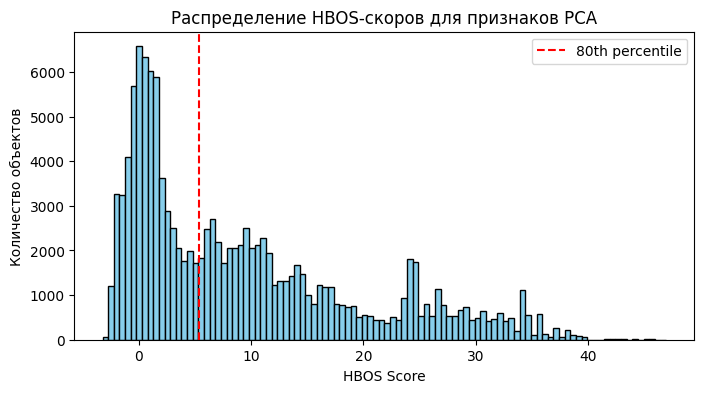

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(hbos_scores, bins=100, color='skyblue', edgecolor='black')
plt.axvline(np.percentile(hbos_scores, 47), color='red', linestyle='--', label='80th percentile')
plt.xlabel('HBOS Score')
plt.ylabel('Количество объектов')
plt.title('Распределение HBOS-скоров для признаков РСА')
plt.legend()
plt.show()

In [ ]:
# поставим границу для аномалий в 0.43
contamination = 0.53
threshold = np.percentile(hbos_scores, 100 * (1 - contamination))
hbos_labels = (hbos_scores > threshold).astype(int)
X_pca_df['hbos_scores_labels_myself'] = hbos_labels
X_pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,hbos_scores_myself,hbos_scores_labels_myself
0,0.688141,-0.040897,-0.654663,0.440501,-0.167428,-0.014799,0.517225,0.289013,-0.174548,8.674638,1
1,-0.540832,0.812078,-3.055177,1.240914,0.106448,0.248122,2.471777,-0.209163,0.635854,20.308051,1
2,-3.680710,-2.106002,0.611452,-0.208981,-0.413370,-0.050222,-0.052378,0.144776,-0.149175,-1.135070,0
3,3.229380,-0.666099,1.562069,-0.616580,-0.362436,-0.000866,0.109335,-0.057172,-0.020329,2.659850,0
4,2.823792,-0.545784,1.261890,-0.635324,0.857064,0.173298,0.205257,0.002931,-0.072751,0.693743,0


In [ ]:
X_pca_df['hbos_scores_labels_myself'].value_counts()

hbos_scores_labels_myself
1    66765
0    59208
Name: count, dtype: int64

In [ ]:
# Также посмортим какие типы атак он выявил в качестве анамалий 
# Переводим в 0 и 1
threshold = np.percentile(hbos_scores, (1 - 0.1) * 100)
preds_dynamic = (hbos_scores >= threshold).astype(int)

# Добавляем в исходный датафрейм
data['hbos_dynamic_label'] = preds_dynamic

# Смотрим какие атаки нашёл динамический режим
data[data['hbos_dynamic_label'] == 1]['attack'].value_counts()

attack
normal             6127
satan              1729
smurf              1242
portsweep          1080
back                763
ipsweep             745
teardrop            382
warezclient         367
pod                  56
guess_passwd         52
buffer_overflow      16
land                 10
loadmodule            7
nmap                  5
ftp_write             5
rootkit               4
neptune               4
imap                  3
spy                   2
multihop              2
warezmaster           1
Name: count, dtype: int64

#### Для стандартизованных данных

In [ ]:
N_BINS = 20           # Количество корзин (каждая содержит примерно N/N_BINS точек)
ALPHA = 1.0           # Параметр сглаживания для избежания нулевых вероятностей

N = X_sc.shape[0]  # Количество строк (объектов)
D = X_sc.shape[1]  # Количество столбцов (признаков)

all_bin_edges = []      # границы корзин для каждого признака
all_bin_widths = []     # ширина каждой корзины (разная!)
all_bin_counts = []     # количество точек в каждой корзине
all_log_tables = []     # логарифмическая таблица L_{j,k}

# ШАГ 1: ДЛЯ КАЖДОГО ПРИЗНАКА СТРОИМ АДАПТИВНЫЕ КОРЗИНЫ

for j in range(D):
    
    feature_j = X_sc[:, j]
    sorted_feature = np.sort(feature_j)
    
    base_size = N // N_BINS        # базовый размер группы
    remainder = N % N_BINS         # остаток (первые remainder групп будут на 1 больше)

    # границы корзин
    bin_edges = [sorted_feature[0]]   # начинаем с минимального значения
    current_idx = 0
    
    for i in range(N_BINS):
        # определяем размер текущей группы
        if i < remainder:
            group_size = base_size + 1
        else:
            group_size = base_size
        
        # перемещаем индекс на размер группы
        current_idx += group_size
        
        # добавляем границу
        if current_idx < N:
            bin_edges.append(sorted_feature[current_idx])
        else:
            # если это последняя группа, добавляем максимальное значение
            if len(bin_edges) <= i + 1:
                bin_edges.append(sorted_feature[-1])


# ШАГ 2 ВЫЧИСЛЯЕМ ЧИСЛА КОРЗИН K_j И ШИРИНЫ 
    
    K_j = len(bin_edges) - 1          # количество корзин для этого признака
    bin_widths = np.zeros(K_j)        # ширина каждой корзины
    bin_counts = np.zeros(K_j)        # количество точек в каждой корзине
    
    # Подсчитываем точки в каждой корзине
    for k in range(K_j):
        left = bin_edges[k]
        right = bin_edges[k + 1]
        
        # Для первой корзины включаем левую границу
        if k == 0:
            count = np.sum((feature_j >= left) & (feature_j <= right))
        else:
            count = np.sum((feature_j > left) & (feature_j <= right))
        
        bin_counts[k] = count
        bin_widths[k] = right - left
        
        # Защита от нулевой ширины
        if bin_widths[k] <= 0:
            bin_widths[k] = 1e-10
    
   
# ШАГ 3: ОЦЕНКА ПЛОТНОСТИ f_{j,k} = (n_{j,k} + α) / ((N + α*K_j) * h_{j,k})
   
    denominator = (N + ALPHA * K_j) * bin_widths
    numerator = bin_counts + ALPHA
    densities = numerator / denominator

    log_table = -np.log(np.maximum(densities, 1e-10))
    
    all_bin_edges.append(bin_edges)
    all_bin_widths.append(bin_widths)
    all_bin_counts.append(bin_counts)
    all_log_tables.append(log_table)
    

# ШАГ 3: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ {a_j, h_j, L_{j,k}} ДЛЯ КАЖДОГО ПРИЗНАКА

hbos_model = {}

for j in range(D):
    hbos_model[j] = {
        'bin_edges': all_bin_edges[j],        # Все границы корзин
        'bin_widths': all_bin_widths[j],      # Ширина каждой корзины (массив, разная!)
        'K_j': len(all_bin_edges[j]) - 1,     # Число корзин
        'L_jk': all_log_tables[j]             # Логарифмическая таблица
    }

print("Сохранённые параметры для каждого признака:")

for j in range(D):  # Показываем первые 5 признаков
    print(f"\nПризнак {j+1}:")
    print(f"  K_{j} = {hbos_model[j]['K_j']}")
    print(f"  Ширина корзин (h_{j}): мин={hbos_model[j]['bin_widths'].min():.4f}, макс={hbos_model[j]['bin_widths'].max():.4f}")


# ШАГ 4: ВЫЧИСЛЕНИЕ HBOS-СКОРА ДЛЯ ОБЪЕКТОВ HBOS(x_i) = Σ L_{j,k} для всех признаков j

hbos_scores = np.zeros(N)

for i in range(N):
    total_score = 0
    
    for j in range(D):
        x_ij = X_sc[i, j]
        
        # Получаем параметры для признака j
        bin_edges = hbos_model[j]['bin_edges']
        K_j = hbos_model[j]['K_j']
        L_jk = hbos_model[j]['L_jk']
        
        # Определяем номер корзины
        k = np.digitize(x_ij, bin_edges) - 1
        k = min(k, K_j - 1)
        k = max(k, 0)
        
        total_score += L_jk[k]

    hbos_scores[i] = total_score

print(f"\nСтатистика HBOS-скоров:")
print(f"  Минимум: {hbos_scores.min():.3f}")
print(f"  Максимум: {hbos_scores.max():.3f}")
print(f"  Средний: {np.mean(hbos_scores):.3f}")
print(f"  Стандартное отклонение: {np.std(hbos_scores):.3f}")


# Находим наиболее аномальные объекты (с наибольшими HBOS-скорами)

print(f"\nТоп-10 наиболее аномальных объектов (индексы): {top_anomalies}")
print(f"Их HBOS-скоры: {hbos_scores[top_anomalies]}")

Сохранённые параметры для каждого признака:

Признак 1:
  K_0 = 20
  Ширина корзин (h_0): мин=0.0000, макс=6.2406

Признак 2:
  K_1 = 20
  Ширина корзин (h_1): мин=0.0000, макс=4.6090

Признак 3:
  K_2 = 20
  Ширина корзин (h_2): мин=0.0000, макс=3.3721

Признак 4:
  K_3 = 20
  Ширина корзин (h_3): мин=0.0000, макс=11.8330

Признак 5:
  K_4 = 20
  Ширина корзин (h_4): мин=0.0000, макс=35.8146

Признак 6:
  K_5 = 20
  Ширина корзин (h_5): мин=0.0000, макс=14.4971

Признак 7:
  K_6 = 20
  Ширина корзин (h_6): мин=0.0000, макс=55.1003

Признак 8:
  K_7 = 20
  Ширина корзин (h_7): мин=0.0000, макс=52.1926

Признак 9:
  K_8 = 20
  Ширина корзин (h_8): мин=0.0000, макс=1.9649

Признак 10:
  K_9 = 20
  Ширина корзин (h_9): мин=0.0000, макс=4.8599

Признак 11:
  K_10 = 20
  Ширина корзин (h_10): мин=0.0000, макс=2.0831

Признак 12:
  K_11 = 20
  Ширина корзин (h_11): мин=0.0000, макс=2.2370

Признак 13:
  K_12 = 20
  Ширина корзин (h_12): мин=0.0000, макс=3.1208

Признак 14:
  K_13 = 20
  Шири

In [ ]:
X_sc_df = pd.DataFrame(X_sc, columns=feature_cols)
X_sc_df['hbos_scores_myself'] = hbos_scores

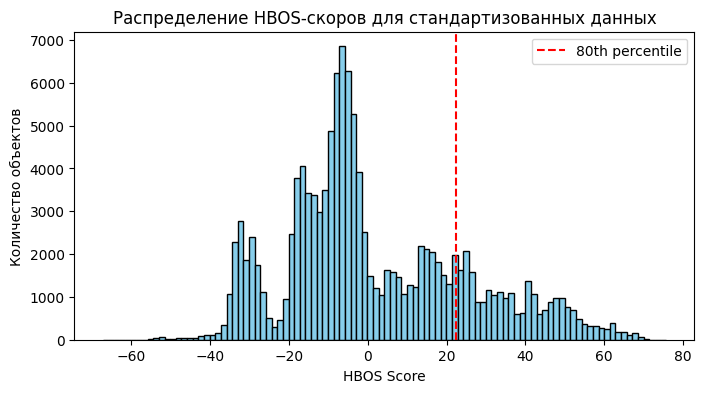

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(hbos_scores, bins=100, color='skyblue', edgecolor='black')
plt.axvline(np.percentile(hbos_scores, 80), color='red', linestyle='--', label='80th percentile')
plt.xlabel('HBOS Score')
plt.ylabel('Количество объектов')
plt.title('Распределение HBOS-скоров для стандартизованных данных')
plt.legend()
plt.show()

In [ ]:
# поставим границу для аномалий в 0.8 
contamination = 0.2
threshold = np.percentile(hbos_scores, 100 * (1 - contamination))
hbos_labels = (hbos_scores > threshold).astype(int)
X_sc_df['hbos_scores_labels_myself'] = hbos_labels
X_sc_df.head()

,duration_log,src_bytes_log,dst_bytes_log,wrong_fragment,hot,hot_log,num_compromised_log,num_root_log,count,srv_count,...,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type_freq,service_freq,flag_freq,logged_in,hbos_scores_myself,hbos_scores_labels_myself
0,-0.221617,0.995517,-0.869111,-0.089486,-0.095076,-0.127866,-0.070058,-0.055255,-0.717045,-0.354343,...,-0.639532,-0.624871,-0.224532,-0.376387,0.475805,-0.728254,0.782064,-0.809262,40.218627,1
1,-0.221617,0.590429,-0.869111,-0.089486,-0.095076,-0.127866,-0.070058,-0.055255,-0.620982,-0.368110,...,-0.639532,-0.624871,-0.387635,-0.376387,-2.030238,-0.881565,0.782064,-0.809262,47.771629,1
2,-0.221617,-1.082990,-0.869111,-0.089486,-0.095076,-0.127866,-0.070058,-0.055255,0.339648,-0.299273,...,1.608759,1.618955,-0.387635,-0.376387,0.475805,0.190812,-0.813914,-0.809262,-0.543123,0
3,-0.221617,0.744881,1.668642,-0.089486,-0.095076,-0.127866,-0.070058,-0.055255,-0.690846,-0.313041,...,-0.572083,-0.602433,-0.387635,-0.345084,0.475805,1.323938,0.782064,1.235694,-12.703457,0
4,-0.221617,0.693670,0.833560,-0.089486,-0.095076,-0.127866,-0.070058,-0.055255,-0.472521,0.058678,...,-0.639532,-0.624871,-0.387635,-0.376387,0.475805,1.323938,0.782064,1.235694,-28.659835,0


In [ ]:
X_sc_df['hbos_scores_labels_myself'].value_counts()

hbos_scores_labels_myself
0    100778
1     25195
Name: count, dtype: int64

#### Для PCA и корзинами = 50

In [ ]:
N_BINS = 50            # Количество корзин (каждая содержит примерно N/N_BINS точек)
ALPHA = 1.0           # Параметр сглаживания для избежания нулевых вероятностей

N = score_new.shape[0]  # Количество строк (объектов)
D = score_new.shape[1]  # Количество столбцов (признаков)

all_bin_edges = []      # границы корзин для каждого признака
all_bin_widths = []     # ширина каждой корзины (разная!)
all_bin_counts = []     # количество точек в каждой корзине
all_log_tables = []     # логарифмическая таблица L_{j,k}

# ШАГ 1: ДЛЯ КАЖДОГО ПРИЗНАКА СТРОИМ АДАПТИВНЫЕ КОРЗИНЫ

for j in range(D):
    
    feature_j = score_new[:, j]
    sorted_feature = np.sort(feature_j)
    
    base_size = N // N_BINS        # базовый размер группы
    remainder = N % N_BINS         # остаток (первые remainder групп будут на 1 больше)

    # границы корзин
    bin_edges = [sorted_feature[0]]   # начинаем с минимального значения
    current_idx = 0
    
    for i in range(N_BINS):
        # определяем размер текущей группы
        if i < remainder:
            group_size = base_size + 1
        else:
            group_size = base_size
        
        # перемещаем индекс на размер группы
        current_idx += group_size
        
        # добавляем границу
        if current_idx < N:
            bin_edges.append(sorted_feature[current_idx])
        else:
            # если это последняя группа, добавляем максимальное значение
            if len(bin_edges) <= i + 1:
                bin_edges.append(sorted_feature[-1])


# ШАГ 2 ВЫЧИСЛЯЕМ ЧИСЛА КОРЗИН K_j И ШИРИНЫ 
    
    K_j = len(bin_edges) - 1          # количество корзин для этого признака
    bin_widths = np.zeros(K_j)        # ширина каждой корзины
    bin_counts = np.zeros(K_j)        # количество точек в каждой корзине
    
    # Подсчитываем точки в каждой корзине
    for k in range(K_j):
        left = bin_edges[k]
        right = bin_edges[k + 1]
        
        # Для первой корзины включаем левую границу
        if k == 0:
            count = np.sum((feature_j >= left) & (feature_j <= right))
        else:
            count = np.sum((feature_j > left) & (feature_j <= right))
        
        bin_counts[k] = count
        bin_widths[k] = right - left
        
        # Защита от нулевой ширины
        if bin_widths[k] <= 0:
            bin_widths[k] = 1e-10
    
   
# ШАГ 3: ОЦЕНКА ПЛОТНОСТИ f_{j,k} = (n_{j,k} + α) / ((N + α*K_j) * h_{j,k})
   
    denominator = (N + ALPHA * K_j) * bin_widths
    numerator = bin_counts + ALPHA
    densities = numerator / denominator

    log_table = -np.log(np.maximum(densities, 1e-10))
    
    all_bin_edges.append(bin_edges)
    all_bin_widths.append(bin_widths)
    all_bin_counts.append(bin_counts)
    all_log_tables.append(log_table)
    

# ШАГ 3: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ {a_j, h_j, L_{j,k}} ДЛЯ КАЖДОГО ПРИЗНАКА

hbos_model = {}

for j in range(D):
    hbos_model[j] = {
        'bin_edges': all_bin_edges[j],        # Все границы корзин
        'bin_widths': all_bin_widths[j],      # Ширина каждой корзины (массив, разная!)
        'K_j': len(all_bin_edges[j]) - 1,     # Число корзин
        'L_jk': all_log_tables[j]             # Логарифмическая таблица
    }

print("Сохранённые параметры для каждого признака:")

for j in range(D):  # Показываем первые 5 признаков
    print(f"\nПризнак {j+1}:")
    print(f"  K_{j} = {hbos_model[j]['K_j']}")
    print(f"  Ширина корзин (h_{j}): мин={hbos_model[j]['bin_widths'].min():.4f}, макс={hbos_model[j]['bin_widths'].max():.4f}")


# ШАГ 4: ВЫЧИСЛЕНИЕ HBOS-СКОРА ДЛЯ ОБЪЕКТОВ HBOS(x_i) = Σ L_{j,k} для всех признаков j

hbos_scores = np.zeros(N)

for i in range(N):
    total_score = 0
    
    for j in range(D):
        x_ij = score_new[i, j]
        
        # Получаем параметры для признака j
        bin_edges = hbos_model[j]['bin_edges']
        K_j = hbos_model[j]['K_j']
        L_jk = hbos_model[j]['L_jk']
        
        # Определяем номер корзины
        k = np.digitize(x_ij, bin_edges) - 1
        k = min(k, K_j - 1)
        k = max(k, 0)
        
        total_score += L_jk[k]

    hbos_scores[i] = total_score

print(f"\nСтатистика HBOS-скоров:")
print(f"  Минимум: {hbos_scores.min():.3f}")
print(f"  Максимум: {hbos_scores.max():.3f}")
print(f"  Средний: {np.mean(hbos_scores):.3f}")
print(f"  Стандартное отклонение: {np.std(hbos_scores):.3f}")


# Находим наиболее аномальные объекты (с наибольшими HBOS-скорами)

print(f"\nТоп-10 наиболее аномальных объектов (индексы): {top_anomalies}")
print(f"Их HBOS-скоры: {hbos_scores[top_anomalies]}")

Сохранённые параметры для каждого признака:

Признак 1:
  K_0 = 50
  Ширина корзин (h_0): мин=0.0428, макс=1.3921

Признак 2:
  K_1 = 50
  Ширина корзин (h_1): мин=0.0041, макс=2.3992

Признак 3:
  K_2 = 50
  Ширина корзин (h_2): мин=0.0254, макс=3.4540

Признак 4:
  K_3 = 50
  Ширина корзин (h_3): мин=0.0079, макс=30.2145

Признак 5:
  K_4 = 50
  Ширина корзин (h_4): мин=0.0289, макс=7.1328

Признак 6:
  K_5 = 50
  Ширина корзин (h_5): мин=0.0038, макс=61.3384

Признак 7:
  K_6 = 50
  Ширина корзин (h_6): мин=0.0199, макс=22.3955

Признак 8:
  K_7 = 50
  Ширина корзин (h_7): мин=0.0085, макс=11.0014

Признак 9:
  K_8 = 50
  Ширина корзин (h_8): мин=0.0049, макс=5.4886

Статистика HBOS-скоров:
  Минимум: -3.385
  Максимум: 52.813
  Средний: 8.318
  Стандартное отклонение: 9.715

Топ-10 наиболее аномальных объектов (индексы): [ 60570  99189  99170  64234  70464 114603  23051  27006   8925 120303]
Их HBOS-скоры: [23.01188548 11.97380499 14.74426431 14.6160842  14.74426431 13.85022138
 14

In [ ]:
X_pca_df = pd.DataFrame(score_new, columns=[f'PC{i+1}' for i in range(score_new.shape[1])])
X_pca_df['hbos_scores_myself'] = hbos_scores

In [ ]:
X_pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,hbos_scores_myself
0,0.688141,-0.040897,-0.654663,0.440501,-0.167428,-0.014799,0.517225,0.289013,-0.174548,8.836965
1,-0.540832,0.812078,-3.055177,1.240914,0.106448,0.248122,2.471777,-0.209163,0.635854,20.630287
2,-3.680710,-2.106002,0.611452,-0.208981,-0.413370,-0.050222,-0.052378,0.144776,-0.149175,-1.048712
3,3.229380,-0.666099,1.562069,-0.616580,-0.362436,-0.000866,0.109335,-0.057172,-0.020329,1.663863
4,2.823792,-0.545784,1.261890,-0.635324,0.857064,0.173298,0.205257,0.002931,-0.072751,0.048535


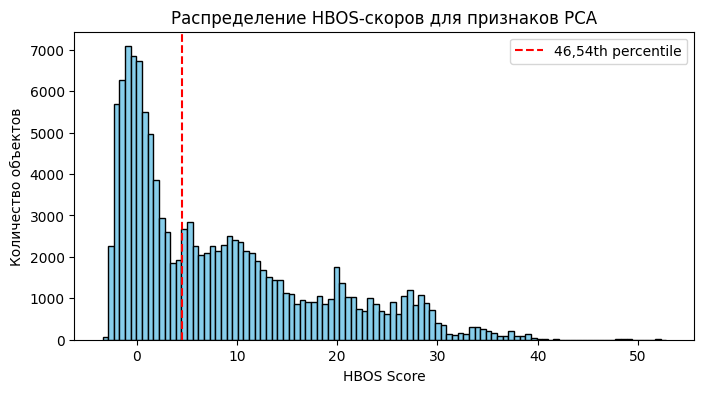

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(hbos_scores, bins=100, color='skyblue', edgecolor='black')
plt.axvline(np.percentile(hbos_scores, 46.54), color='red', linestyle='--', label='46,54th percentile')
plt.xlabel('HBOS Score')
plt.ylabel('Количество объектов')
plt.title('Распределение HBOS-скоров для признаков РСА')
plt.legend()
plt.show()

In [ ]:
# поставим границу для аномалий 
contamination = 0.5346
threshold = np.percentile(hbos_scores, 100 * (1 - contamination))
hbos_labels = (hbos_scores > threshold).astype(int)
X_pca_df['hbos_scores_labels_myself'] = hbos_labels
X_pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,hbos_scores_myself,hbos_scores_labels_myself
0,0.688141,-0.040897,-0.654663,0.440501,-0.167428,-0.014799,0.517225,0.289013,-0.174548,8.836965,1
1,-0.540832,0.812078,-3.055177,1.240914,0.106448,0.248122,2.471777,-0.209163,0.635854,20.630287,1
2,-3.680710,-2.106002,0.611452,-0.208981,-0.413370,-0.050222,-0.052378,0.144776,-0.149175,-1.048712,0
3,3.229380,-0.666099,1.562069,-0.616580,-0.362436,-0.000866,0.109335,-0.057172,-0.020329,1.663863,0
4,2.823792,-0.545784,1.261890,-0.635324,0.857064,0.173298,0.205257,0.002931,-0.072751,0.048535,0


In [ ]:
X_pca_df['hbos_scores_labels_myself'].value_counts()

hbos_scores_labels_myself
1    67345
0    58628
Name: count, dtype: int64

#### Для стандартизованных данных с корзинами = 30

In [ ]:
N_BINS = 30           # Количество корзин (каждая содержит примерно N/N_BINS точек)
ALPHA = 1.0           # Параметр сглаживания для избежания нулевых вероятностей

N = X_sc.shape[0]  # Количество строк (объектов)
D = X_sc.shape[1]  # Количество столбцов (признаков)

all_bin_edges = []      # границы корзин для каждого признака
all_bin_widths = []     # ширина каждой корзины (разная!)
all_bin_counts = []     # количество точек в каждой корзине
all_log_tables = []     # логарифмическая таблица L_{j,k}

# ШАГ 1: ДЛЯ КАЖДОГО ПРИЗНАКА СТРОИМ АДАПТИВНЫЕ КОРЗИНЫ

for j in range(D):
    
    feature_j = X_sc[:, j]
    sorted_feature = np.sort(feature_j)
    
    base_size = N // N_BINS        # базовый размер группы
    remainder = N % N_BINS         # остаток (первые remainder групп будут на 1 больше)

    # границы корзин
    bin_edges = [sorted_feature[0]]   # начинаем с минимального значения
    current_idx = 0
    
    for i in range(N_BINS):
        # определяем размер текущей группы
        if i < remainder:
            group_size = base_size + 1
        else:
            group_size = base_size
        
        # перемещаем индекс на размер группы
        current_idx += group_size
        
        # добавляем границу
        if current_idx < N:
            bin_edges.append(sorted_feature[current_idx])
        else:
            # если это последняя группа, добавляем максимальное значение
            if len(bin_edges) <= i + 1:
                bin_edges.append(sorted_feature[-1])


# ШАГ 2 ВЫЧИСЛЯЕМ ЧИСЛА КОРЗИН K_j И ШИРИНЫ 
    
    K_j = len(bin_edges) - 1          # количество корзин для этого признака
    bin_widths = np.zeros(K_j)        # ширина каждой корзины
    bin_counts = np.zeros(K_j)        # количество точек в каждой корзине
    
    # Подсчитываем точки в каждой корзине
    for k in range(K_j):
        left = bin_edges[k]
        right = bin_edges[k + 1]
        
        # Для первой корзины включаем левую границу
        if k == 0:
            count = np.sum((feature_j >= left) & (feature_j <= right))
        else:
            count = np.sum((feature_j > left) & (feature_j <= right))
        
        bin_counts[k] = count
        bin_widths[k] = right - left
        
        # Защита от нулевой ширины
        if bin_widths[k] <= 0:
            bin_widths[k] = 1e-10
    
   
# ШАГ 3: ОЦЕНКА ПЛОТНОСТИ f_{j,k} = (n_{j,k} + α) / ((N + α*K_j) * h_{j,k})
   
    denominator = (N + ALPHA * K_j) * bin_widths
    numerator = bin_counts + ALPHA
    densities = numerator / denominator

    log_table = -np.log(np.maximum(densities, 1e-10))
    
    all_bin_edges.append(bin_edges)
    all_bin_widths.append(bin_widths)
    all_bin_counts.append(bin_counts)
    all_log_tables.append(log_table)
    

# ШАГ 3: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ {a_j, h_j, L_{j,k}} ДЛЯ КАЖДОГО ПРИЗНАКА

hbos_model = {}

for j in range(D):
    hbos_model[j] = {
        'bin_edges': all_bin_edges[j],        # Все границы корзин
        'bin_widths': all_bin_widths[j],      # Ширина каждой корзины (массив, разная!)
        'K_j': len(all_bin_edges[j]) - 1,     # Число корзин
        'L_jk': all_log_tables[j]             # Логарифмическая таблица
    }

print("Сохранённые параметры для каждого признака:")

for j in range(D):  # Показываем первые 5 признаков
    print(f"\nПризнак {j+1}:")
    print(f"  K_{j} = {hbos_model[j]['K_j']}")
    print(f"  Ширина корзин (h_{j}): мин={hbos_model[j]['bin_widths'].min():.4f}, макс={hbos_model[j]['bin_widths'].max():.4f}")


# ШАГ 4: ВЫЧИСЛЕНИЕ HBOS-СКОРА ДЛЯ ОБЪЕКТОВ HBOS(x_i) = Σ L_{j,k} для всех признаков j

hbos_scores = np.zeros(N)

for i in range(N):
    total_score = 0
    
    for j in range(D):
        x_ij = X_sc[i, j]
        
        # Получаем параметры для признака j
        bin_edges = hbos_model[j]['bin_edges']
        K_j = hbos_model[j]['K_j']
        L_jk = hbos_model[j]['L_jk']
        
        # Определяем номер корзины
        k = np.digitize(x_ij, bin_edges) - 1
        k = min(k, K_j - 1)
        k = max(k, 0)
        
        total_score += L_jk[k]

    hbos_scores[i] = total_score

print(f"\nСтатистика HBOS-скоров:")
print(f"  Минимум: {hbos_scores.min():.3f}")
print(f"  Максимум: {hbos_scores.max():.3f}")
print(f"  Средний: {np.mean(hbos_scores):.3f}")
print(f"  Стандартное отклонение: {np.std(hbos_scores):.3f}")


# Находим наиболее аномальные объекты (с наибольшими HBOS-скорами)

print(f"\nТоп-10 наиболее аномальных объектов (индексы): {top_anomalies}")
print(f"Их HBOS-скоры: {hbos_scores[top_anomalies]}")

Сохранённые параметры для каждого признака:

Признак 1:
  K_0 = 30
  Ширина корзин (h_0): мин=0.0000, макс=5.0536

Признак 2:
  K_1 = 30
  Ширина корзин (h_1): мин=0.0000, макс=4.4410

Признак 3:
  K_2 = 30
  Ширина корзин (h_2): мин=0.0000, макс=3.2996

Признак 4:
  K_3 = 30
  Ширина корзин (h_3): мин=0.0000, макс=11.8330

Признак 5:
  K_4 = 30
  Ширина корзин (h_4): мин=0.0000, макс=35.8146

Признак 6:
  K_5 = 30
  Ширина корзин (h_5): мин=0.0000, макс=14.4971

Признак 7:
  K_6 = 30
  Ширина корзин (h_6): мин=0.0000, макс=55.1003

Признак 8:
  K_7 = 30
  Ширина корзин (h_7): мин=0.0000, макс=52.1926

Признак 9:
  K_8 = 30
  Ширина корзин (h_8): мин=0.0000, макс=1.8601

Признак 10:
  K_9 = 30
  Ширина корзин (h_9): мин=0.0000, макс=4.0889

Признак 11:
  K_10 = 30
  Ширина корзин (h_10): мин=0.0000, макс=2.0831

Признак 12:
  K_11 = 30
  Ширина корзин (h_11): мин=0.0000, макс=2.2370

Признак 13:
  K_12 = 30
  Ширина корзин (h_12): мин=0.0000, макс=3.1208

Признак 14:
  K_13 = 30
  Шири

In [ ]:
X_sc_df = pd.DataFrame(X_sc, columns=feature_cols)
X_sc_df['hbos_scores_myself'] = hbos_scores

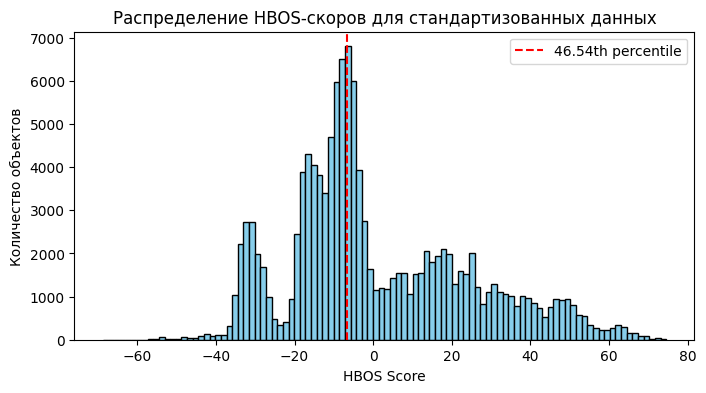

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(hbos_scores, bins=100, color='skyblue', edgecolor='black')
plt.axvline(np.percentile(hbos_scores, 46.54), color='red', linestyle='--', label='46.54th percentile')
plt.xlabel('HBOS Score')
plt.ylabel('Количество объектов')
plt.title('Распределение HBOS-скоров для стандартизованных данных')
plt.legend()
plt.show()

In [ ]:
# поставим границу для аномалий в 0.8 
contamination = 0.5346
threshold = np.percentile(hbos_scores, 100 * (1 - contamination))
hbos_labels = (hbos_scores > threshold).astype(int)
X_sc_df['hbos_scores_labels_myself'] = hbos_labels
X_sc_df.head()

,duration_log,src_bytes_log,dst_bytes_log,wrong_fragment,hot,hot_log,num_compromised_log,num_root_log,count,srv_count,...,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type_freq,service_freq,flag_freq,logged_in,hbos_scores_myself,hbos_scores_labels_myself
0,-0.221617,0.995517,-0.869111,-0.089486,-0.095076,-0.127866,-0.070058,-0.055255,-0.717045,-0.354343,...,-0.639532,-0.624871,-0.224532,-0.376387,0.475805,-0.728254,0.782064,-0.809262,39.484304,1
1,-0.221617,0.590429,-0.869111,-0.089486,-0.095076,-0.127866,-0.070058,-0.055255,-0.620982,-0.368110,...,-0.639532,-0.624871,-0.387635,-0.376387,-2.030238,-0.881565,0.782064,-0.809262,47.402374,1
2,-0.221617,-1.082990,-0.869111,-0.089486,-0.095076,-0.127866,-0.070058,-0.055255,0.339648,-0.299273,...,1.608759,1.618955,-0.387635,-0.376387,0.475805,0.190812,-0.813914,-0.809262,-1.977818,1
3,-0.221617,0.744881,1.668642,-0.089486,-0.095076,-0.127866,-0.070058,-0.055255,-0.690846,-0.313041,...,-0.572083,-0.602433,-0.387635,-0.345084,0.475805,1.323938,0.782064,1.235694,-14.880491,0
4,-0.221617,0.693670,0.833560,-0.089486,-0.095076,-0.127866,-0.070058,-0.055255,-0.472521,0.058678,...,-0.639532,-0.624871,-0.387635,-0.376387,0.475805,1.323938,0.782064,1.235694,-27.386749,0


In [ ]:
X_sc_df['hbos_scores_labels_myself'].value_counts()

hbos_scores_labels_myself
1    67339
0    58634
Name: count, dtype: int64